# SiNAPS end-to-end spike-sorting pipeline

This notebook is a linear, reproducible SpikeInterface workflow for selecting a SiNAPS raw recording,
removing low-variance dead channels, estimating motion with DREDge, running either Kilosort4 or the
independent externally corrected LUPIN branch, and evaluating units with a disk-backed `SortingAnalyzer`.

The configured analysis target is the complete `30Connell_1.dat` recording. Existing motion, materialized
recordings, sorting, and analyzer results are never overwritten. Every heavy stage is independently fail-closed:
a new heavy run starts only after its explicit execution flag and storage-safety confirmation are enabled.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"D:\SPIHackerthon\spikeinterface")

RECORDINGS = {
    "30Connell_0": {
        "dat_path": PROJECT_ROOT / "30Connell_0.dat",
        "prb_path": PROJECT_ROOT / "SiNAPS_v_1_6_kilosortChanMap.prb",
        "sampling_frequency": 20_000.0,
        "num_channels": 1024,
        "dtype": "int16",
        "gain_to_uV": 5.85,
        "offset_to_uV": 150.0,
    },
    "30Connell_1": {
        "dat_path": Path(r"E:\30Connell_1.dat"),
        "prb_path": PROJECT_ROOT / "SiNAPS_v_1_6_kilosortChanMap.prb",
        "sampling_frequency": 20_000.0,
        "num_channels": 1024,
        "dtype": "int16",
        "gain_to_uV": 5.85,
        "offset_to_uV": 150.0,
    },
}

SELECTED_RECORDING_ID = "30Connell_1"
RUN_MODE = "full"  # "pilot" or "full"
PILOT_START_S = 0.0
PILOT_DURATION_S = 300.0

MOTION_OUTPUT_ROOT = PROJECT_ROOT / "motion_outputs"
RUN_ID = "dredge_clean_bandpass_30um_v1"
REUSE_EXISTING = True
RUN_MOTION_ESTIMATION = False

# Heavy sorting remains disabled until all inputs and outputs have been copied to a healthy physical disk.
# Before enabling it, update RECORDINGS[SELECTED_RECORDING_ID]["dat_path"] and MOTION_OUTPUT_ROOT.
RUN_SORTING_AND_QC = False
CONFIRM_HEALTHY_STORAGE = False
SORTING_OUTPUT_ROOT = None  # Set to a Path on a healthy physical disk before enabling sorting.
SORTING_RUN_ID = "kilosort4_nonrigid5_default_v1"
REUSE_EXISTING_SORTING = True
MIN_SORTING_FREE_SPACE_GIB = 150.0
UNSAFE_DISK_SERIALS = {
    "0000_0000_0000_0000_00E0_4C12_F95B_6C64.",
}

LOW_STD_NUM_CHUNKS = 50
LOW_STD_CHUNK_DURATION = "500ms"
LOW_STD_SEED = 0
LOW_STD_THRESHOLD = None  # None uses the lower-half maximum-gap rule.

BANDPASS_FREQ_MIN_HZ = 300.0
BANDPASS_FREQ_MAX_HZ = 6000.0

DREDGE_PRESET = "dredge"
DREDGE_DETECT_METHOD = "locally_exclusive"
DREDGE_PEAK_SIGN = "both"
DREDGE_DETECT_THRESHOLD = 5.0
DREDGE_N_JOBS = 8
DREDGE_CHUNK_DURATION = "1s"

# Full LUPIN branch: all execution is fail-closed by default.
LUPIN_STORAGE_ROOT = None
CONFIRM_HEALTHY_LUPIN_STORAGE = False
RUN_LUPIN_MATERIALIZATION = False
RUN_LUPIN_SORTING = False
RUN_LUPIN_QC = False
LUPIN_MIN_FREE_SPACE_GIB = 300
LUPIN_SEED = 0

# Synthetic validation is separate from the direct-full real-data decision and also defaults off.
RUN_LUPIN_SYNTHETIC_VALIDATION = False

assert SELECTED_RECORDING_ID in RECORDINGS
assert RUN_MODE in {"pilot", "full"}
selected_recording_config = RECORDINGS[SELECTED_RECORDING_ID]
selected_recording_config

{'dat_path': WindowsPath('E:/30Connell_1.dat'),
 'prb_path': WindowsPath('D:/SPIHackerthon/spikeinterface/SiNAPS_v_1_6_kilosortChanMap.prb'),
 'sampling_frequency': 20000.0,
 'num_channels': 1024,
 'dtype': 'int16',
 'gain_to_uV': 5.85,
 'offset_to_uV': 150.0}

In [2]:
import hashlib
import importlib.metadata
import json
import platform
import subprocess
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import probeinterface
import spikeinterface
import spikeinterface.full as si
import torch
from probeinterface import read_prb
from probeinterface.plotting import plot_probe
from spikeinterface.core import BinaryRecordingExtractor, get_random_data_chunks
from spikeinterface.sortingcomponents.motion import correct_motion_on_peaks

assert torch.cuda.is_available(), "This pipeline requires CUDA for DREDge motion estimation."

try:
    git_head = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()
except (OSError, subprocess.CalledProcessError):
    git_head = None

environment_info = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "spikeinterface": spikeinterface.__version__,
    "probeinterface": probeinterface.__version__,
    "numpy": np.__version__,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(0),
    "git_head": git_head,
}

print(json.dumps(environment_info, indent=2))

{
  "generated_at_utc": "2026-07-13T22:51:12.391576+00:00",
  "python": "3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:27:10) [MSC v.1944 64 bit (AMD64)]",
  "platform": "Windows-10-10.0.19045-SP0",
  "spikeinterface": "0.104.1",
  "probeinterface": "0.3.2",
  "numpy": "2.4.4",
  "torch": "2.11.0+cu128",
  "cuda_available": true,
  "cuda_device": "NVIDIA GeForce RTX 4090",
  "git_head": "3657ed48a6b7c286436c64b16013f863a63f86c8"
}


PRB: D:\SPIHackerthon\spikeinterface\SiNAPS_v_1_6_kilosortChanMap.prb
contacts: 1024
x positions (um): [ 0. 30. 60. 90.]
y pitch (um): 30.0


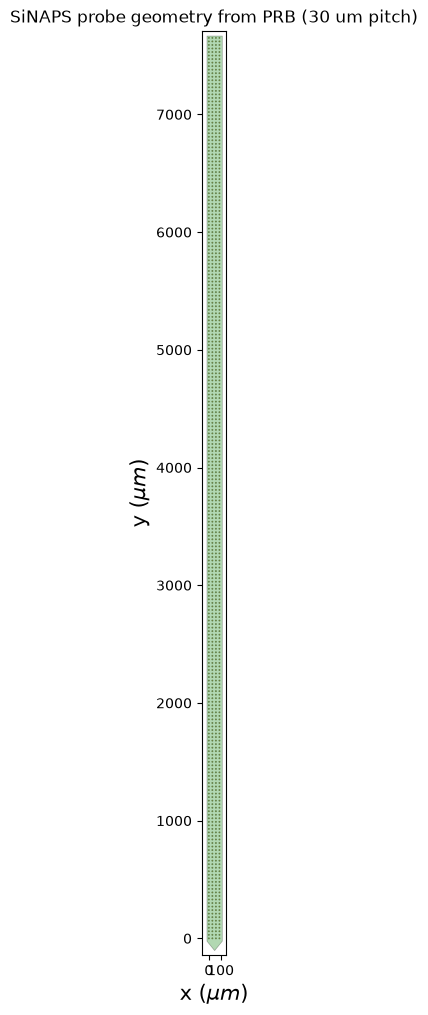

In [3]:
prb_path = Path(selected_recording_config["prb_path"]).resolve()
probe_group = read_prb(prb_path)

assert len(probe_group.probes) == 1, "Expected exactly one probe in the PRB file."
probe = probe_group.probes[0]
contact_positions = np.asarray(probe.contact_positions, dtype=float)
device_channel_indices = np.asarray(probe.device_channel_indices)

unique_x_um = np.unique(contact_positions[:, 0])
unique_y_um = np.unique(contact_positions[:, 1])
pitch_y_um = float(np.median(np.diff(unique_y_um)))

assert probe.get_contact_count() == 1024
assert np.array_equal(np.sort(device_channel_indices), np.arange(1024))
assert unique_x_um.size == 4
assert unique_y_um.size == 256
assert np.isclose(pitch_y_um, 30.0)

print("PRB:", prb_path)
print("contacts:", probe.get_contact_count())
print("x positions (um):", unique_x_um)
print("y pitch (um):", pitch_y_um)

fig, ax = plt.subplots(figsize=(6, 12))
plot_probe(probe, ax=ax, with_contact_id=False)
ax.set_title("SiNAPS probe geometry from PRB (30 um pitch)")
plt.show()

In [4]:
dat_path = Path(selected_recording_config["dat_path"]).resolve()

recording_raw = BinaryRecordingExtractor(
    file_paths=dat_path,
    sampling_frequency=selected_recording_config["sampling_frequency"],
    num_channels=selected_recording_config["num_channels"],
    dtype=selected_recording_config["dtype"],
    gain_to_uV=selected_recording_config["gain_to_uV"],
    offset_to_uV=selected_recording_config["offset_to_uV"],
)
recording_raw.set_probe(probe)

# DREDge preprocessing needs floating-point traces. Keep the original int16 extractor for Kilosort4.
recording = recording_raw.astype("float32")

recording_duration_s = recording.get_total_duration()

print(recording)
print("data:", dat_path)
print("channels:", recording.get_num_channels())
print("duration (s):", recording_duration_s)
print("motion-analysis dtype:", recording.get_dtype())
print("sorting-source dtype:", recording_raw.get_dtype())

astype (AstypeRecording): 1024 channels - 20.0kHz - 1 segments - 31,780,000 samples 
        1,589.00s (26.48 minutes) - float32 dtype - 121.23 GiB
data: E:\30Connell_1.dat
channels: 1024
duration (s): 1589.0
motion-analysis dtype: float32
sorting-source dtype: int16


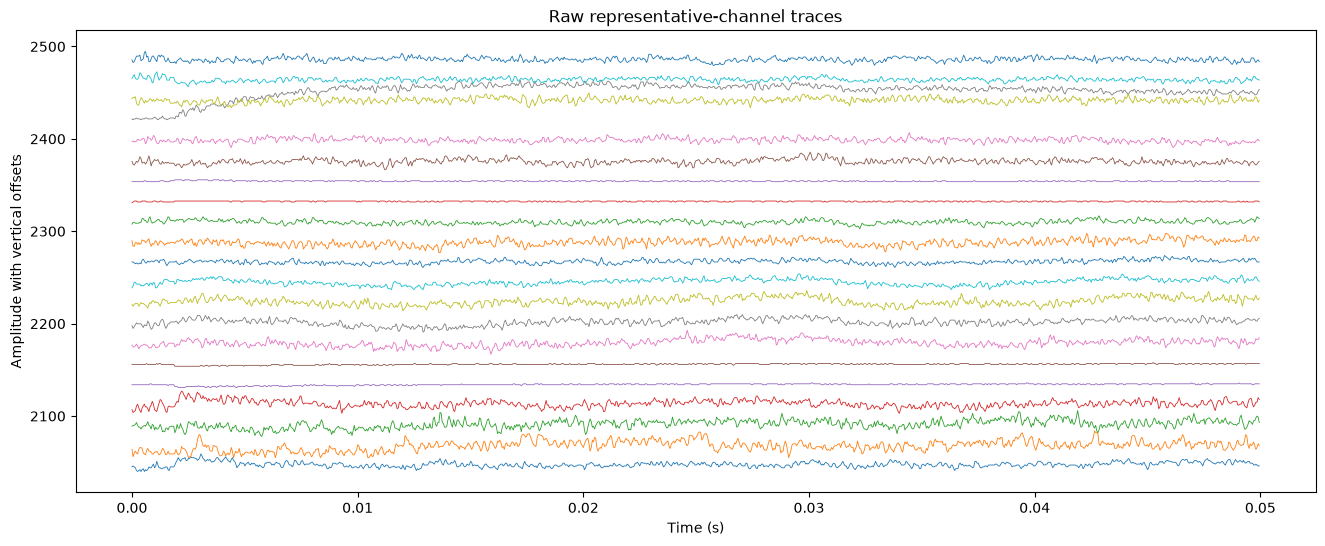

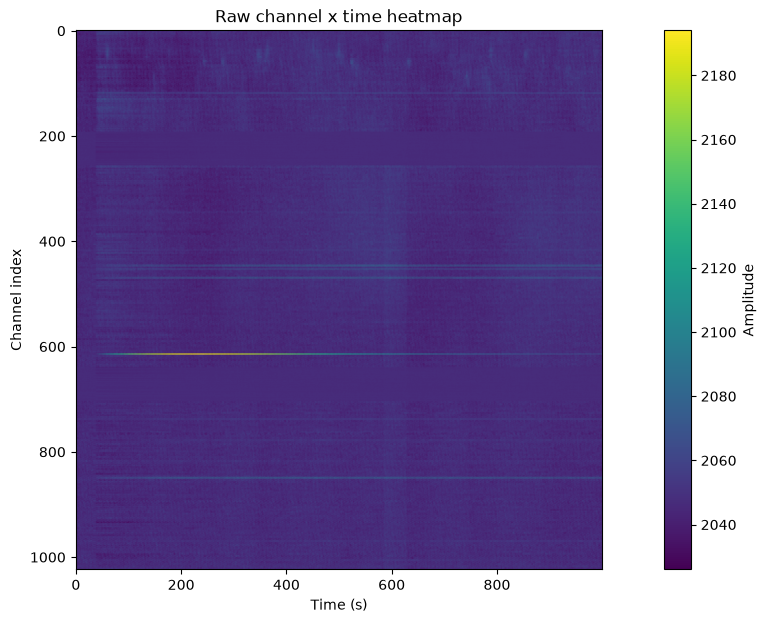

In [5]:
RAW_QC_START_S = 0.0
RAW_QC_DURATION_S = 1.0

sampling_frequency = recording.get_sampling_frequency()
raw_qc_start_frame = int(round(RAW_QC_START_S * sampling_frequency))
raw_qc_end_frame = int(round((RAW_QC_START_S + RAW_QC_DURATION_S) * sampling_frequency))
raw_qc_traces = recording.get_traces(
    0,
    0,
    1000,
)

representative_channel_ids = np.asarray(recording.get_channel_ids())[::50]
representative_indices = recording.ids_to_indices(representative_channel_ids)
representative_traces = raw_qc_traces[:, representative_indices]
representative_scale = np.median(np.std(representative_traces, axis=0))
representative_offsets = np.arange(representative_traces.shape[1]) * max(1.0, 8.0 * representative_scale)
raw_qc_time_s = np.arange(raw_qc_traces.shape[0]) / sampling_frequency + RAW_QC_START_S

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(raw_qc_time_s, representative_traces + representative_offsets, linewidth=0.6)
ax.set_title("Raw representative-channel traces")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude with vertical offsets")
plt.show()

raw_heatmap_limit = float(np.nanpercentile(np.abs(raw_qc_traces), 99.5))
fig, ax = plt.subplots(figsize=(16, 7))
image = ax.imshow(
    raw_qc_traces.T
)
ax.set_title("Raw channel x time heatmap")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Channel index")
fig.colorbar(image, ax=ax, label="Amplitude")
plt.show()

Low-STD threshold: 1.9449350833892822
Dead-channel count: 140
Dead-channel IDs: [117 119 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207
 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225
 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243
 244 245 246 247 248 249 250 251 252 253 254 255 445 447 452 454 468 470
 640 641 642 643 644 645 646 647 648 649 650 651 652 653 654 655 656 657
 658 659 660 661 662 663 664 665 666 667 668 669 670 671 672 673 674 675
 676 677 678 679 680 681 682 683 684 685 686 687 688 689 690 691 692 693
 694 695 696 697 698 699 700 701 702 703 737 739 848 850]


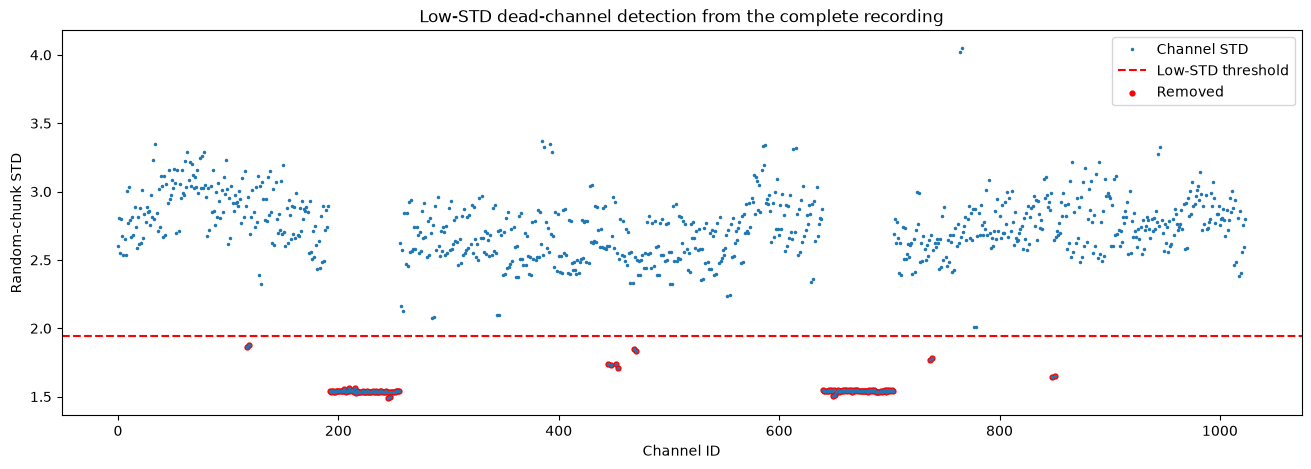

In [6]:
random_chunks = get_random_data_chunks(
    recording,
    num_chunks_per_segment=LOW_STD_NUM_CHUNKS,
    chunk_duration=LOW_STD_CHUNK_DURATION,
    return_in_uV=False,
    concatenated=True,
    seed=LOW_STD_SEED,
)

all_channel_ids = np.asarray(recording.get_channel_ids())
channel_stds = random_chunks.std(axis=0)
finite_std_mask = np.isfinite(channel_stds)
sorted_finite_stds = np.sort(channel_stds[finite_std_mask])

if LOW_STD_THRESHOLD is None:
    lower_half_stds = sorted_finite_stds[
        sorted_finite_stds <= np.percentile(sorted_finite_stds, 50)
    ]
    assert lower_half_stds.size >= 2, "Not enough finite channel STD values to estimate a threshold."
    lower_half_gaps = np.diff(lower_half_stds)
    largest_gap_index = int(np.argmax(lower_half_gaps))
    low_std_threshold = float(
        0.5 * (lower_half_stds[largest_gap_index] + lower_half_stds[largest_gap_index + 1])
    )
else:
    low_std_threshold = float(LOW_STD_THRESHOLD)

dead_channel_mask = (~finite_std_mask) | (channel_stds < low_std_threshold)
dead_channel_ids = all_channel_ids[dead_channel_mask]

print("Low-STD threshold:", low_std_threshold)
print("Dead-channel count:", dead_channel_ids.size)
print("Dead-channel IDs:", dead_channel_ids)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(all_channel_ids, channel_stds, ".", markersize=3, label="Channel STD")
ax.axhline(low_std_threshold, color="red", linestyle="--", label="Low-STD threshold")
ax.scatter(dead_channel_ids, channel_stds[dead_channel_mask], color="red", s=12, label="Removed")
ax.set_title("Low-STD dead-channel detection from the complete recording")
ax.set_xlabel("Channel ID")
ax.set_ylabel("Random-chunk STD")
ax.legend()
plt.show()

In [6]:
recording_clean = recording.remove_channels(dead_channel_ids)
recording_clean_raw = recording_raw.remove_channels(dead_channel_ids)
retained_channel_ids = np.asarray(recording_clean.get_channel_ids())

print("Original channels:", recording.get_num_channels())
print("Retained channels:", recording_clean.get_num_channels())
print("Removed channels:", recording.get_num_channels() - recording_clean.get_num_channels())
print("Dead IDs still present:", np.intersect1d(dead_channel_ids, retained_channel_ids))

clean_qc_traces = recording_clean.get_traces(
    segment_index=0,
    start_frame=raw_qc_start_frame,
    end_frame=raw_qc_end_frame,
)
shared_heatmap_limit = max(
    float(np.nanpercentile(np.abs(raw_qc_traces), 99.5)),
    float(np.nanpercentile(np.abs(clean_qc_traces), 99.5)),
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, traces, title in zip(
    axes,
    [raw_qc_traces, clean_qc_traces],
    ["Before Low-STD removal", "After Low-STD removal"],
):
    image = ax.imshow(
        traces[::10].T,
        aspect="auto",
        origin="lower",
        cmap="RdBu_r",
        vmin=-shared_heatmap_limit,
        vmax=shared_heatmap_limit,
        extent=[RAW_QC_START_S, RAW_QC_START_S + RAW_QC_DURATION_S, 0, traces.shape[1]],
    )
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Current channel index")
fig.colorbar(image, ax=axes, label="Amplitude", shrink=0.8)
plt.show()

shared_representative_ids = np.intersect1d(representative_channel_ids, retained_channel_ids)
before_representative = recording.get_traces(
    segment_index=0,
    start_frame=raw_qc_start_frame,
    end_frame=raw_qc_end_frame,
    channel_ids=shared_representative_ids,
)
after_representative = recording_clean.get_traces(
    segment_index=0,
    start_frame=raw_qc_start_frame,
    end_frame=raw_qc_end_frame,
    channel_ids=shared_representative_ids,
)
shared_scale = np.median(np.std(before_representative, axis=0))
shared_offsets = np.arange(shared_representative_ids.size) * max(1.0, 8.0 * shared_scale)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)
axes[0].plot(raw_qc_time_s, before_representative + shared_offsets, linewidth=0.6)
axes[0].set_title("Shared channels before removal")
axes[1].plot(raw_qc_time_s, after_representative + shared_offsets, linewidth=0.6)
axes[1].set_title("Shared channels after removal")
for ax in axes:
    ax.set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude with vertical offsets")
plt.show()

NameError: name 'dead_channel_ids' is not defined

In [8]:
if RUN_MODE == "pilot":
    analysis_start_frame = int(round(PILOT_START_S * sampling_frequency))
    analysis_end_frame = int(round((PILOT_START_S + PILOT_DURATION_S) * sampling_frequency))
    recording_for_analysis = recording_clean.frame_slice(
        start_frame=analysis_start_frame,
        end_frame=analysis_end_frame,
    )
else:
    analysis_start_frame = 0
    analysis_end_frame = recording_clean.get_num_frames(segment_index=0)
    recording_for_analysis = recording_clean

recording_for_motion = si.bandpass_filter(
    recording_for_analysis,
    freq_min=BANDPASS_FREQ_MIN_HZ,
    freq_max=BANDPASS_FREQ_MAX_HZ,
)

analysis_duration_s = recording_for_motion.get_total_duration()
print("Run mode:", RUN_MODE)
print("Analysis frames:", analysis_start_frame, analysis_end_frame)
print("Analysis duration (s):", analysis_duration_s)
print(recording_for_motion)

Run mode: full
Analysis frames: 0 31780000
Analysis duration (s): 1589.0
BandpassFilterRecording: 884 channels - 20.0kHz - 1 segments - 31,780,000 samples 
                         1,589.00s (26.48 minutes) - float32 dtype - 104.66 GiB


In [9]:
dat_file_stat = dat_path.stat()
probe_geometry_hash = hashlib.sha256(contact_positions.astype("<f8").tobytes()).hexdigest()

run_config = {
    "recording_id": SELECTED_RECORDING_ID,
    "run_mode": RUN_MODE,
    "pilot_start_s": PILOT_START_S,
    "pilot_duration_s": PILOT_DURATION_S,
    "sampling_frequency": selected_recording_config["sampling_frequency"],
    "num_channels": selected_recording_config["num_channels"],
    "dtype": selected_recording_config["dtype"],
    "gain_to_uV": selected_recording_config["gain_to_uV"],
    "offset_to_uV": selected_recording_config["offset_to_uV"],
    "prb_path": str(prb_path),
    "probe_geometry_hash": probe_geometry_hash,
    "removed_channel_ids": dead_channel_ids.tolist(),
    "low_std": {
        "num_chunks_per_segment": LOW_STD_NUM_CHUNKS,
        "chunk_duration": LOW_STD_CHUNK_DURATION,
        "seed": LOW_STD_SEED,
        "configured_threshold": LOW_STD_THRESHOLD,
        "resolved_threshold": low_std_threshold,
    },
    "bandpass_hz": [BANDPASS_FREQ_MIN_HZ, BANDPASS_FREQ_MAX_HZ],
    "dredge": {
        "preset": DREDGE_PRESET,
        "detect_method": DREDGE_DETECT_METHOD,
        "peak_sign": DREDGE_PEAK_SIGN,
        "detect_threshold": DREDGE_DETECT_THRESHOLD,
        "estimator_device": "cuda",
        "n_jobs": DREDGE_N_JOBS,
        "chunk_duration": DREDGE_CHUNK_DURATION,
    },
}
config_fingerprint = hashlib.sha256(
    json.dumps(run_config, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

data_identity = {
    "path": str(dat_path),
    "size_bytes": dat_file_stat.st_size,
    "mtime_ns": dat_file_stat.st_mtime_ns,
}

run_folder = MOTION_OUTPUT_ROOT / SELECTED_RECORDING_ID / f"{RUN_MODE}_{RUN_ID}"
motion_folder = run_folder / "motion_info"
provenance_path = run_folder / "provenance.json"

recording_motion_root = MOTION_OUTPUT_ROOT / SELECTED_RECORDING_ID
available_runs = []
if recording_motion_root.is_dir():
    available_runs = sorted(
        path.name
        for path in recording_motion_root.iterdir()
        if path.is_dir()
        and (path / "motion_info" / "parameters.json").is_file()
        and (path / "motion_info" / "peaks.npy").is_file()
        and (path / "motion_info" / "peak_locations.npy").is_file()
    )

print("Available complete runs:", available_runs)
print("Selected run folder:", run_folder)
print("Configuration fingerprint:", config_fingerprint)

Available complete runs: ['full_dredge_clean_bandpass_30um_v1', 'pilot_dredge_clean_bandpass_30um_v1']
Selected run folder: D:\SPIHackerthon\spikeinterface\motion_outputs\30Connell_1\full_dredge_clean_bandpass_30um_v1
Configuration fingerprint: 8fcc5fe53223185f75ec0483882f53adf11ea92a58c263ed6187703558155adc


In [10]:
computed_new_run = False

if run_folder.exists():
    if not REUSE_EXISTING:
        raise FileExistsError(
            f"Run folder already exists: {run_folder}. Choose a new RUN_ID or enable REUSE_EXISTING."
        )
    if not provenance_path.is_file() or not motion_folder.is_dir():
        raise RuntimeError(f"Existing run is incomplete and will not be overwritten: {run_folder}")

    stored_provenance = json.loads(provenance_path.read_text(encoding="utf-8"))
    assert stored_provenance["config_fingerprint"] == config_fingerprint, "Stored configuration differs."
    stored_data_identity = stored_provenance["data_identity"]
    assert stored_data_identity["size_bytes"] == data_identity["size_bytes"], "Stored data size differs."
    assert stored_data_identity["mtime_ns"] == data_identity["mtime_ns"], "Stored data mtime differs."
    if stored_data_identity["path"] != data_identity["path"]:
        print(
            "Motion provenance path changed after a verified file relocation:",
            stored_data_identity["path"],
            "->",
            data_identity["path"],
        )
    assert stored_provenance["probe_geometry_hash"] == probe_geometry_hash, "Stored probe differs."

    motion_info = si.load_motion_info(motion_folder)
    motion = motion_info["motion"]
    print("Reused existing motion result:", motion_folder)

else:
    if not RUN_MOTION_ESTIMATION:
        raise RuntimeError(
            f"No reusable motion result exists at {run_folder}, and RUN_MOTION_ESTIMATION is False. "
            "Copy a validated run to the configured healthy MOTION_OUTPUT_ROOT or explicitly enable estimation."
        )
    run_folder.mkdir(parents=True, exist_ok=False)
    initial_provenance = {
        "status": "running",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "config_fingerprint": config_fingerprint,
        "data_identity": data_identity,
        "probe_geometry_hash": probe_geometry_hash,
        "environment": environment_info,
        "run_config": run_config,
        "retained_channel_ids": retained_channel_ids.tolist(),
        "channel_stds": channel_stds.tolist(),
    }
    provenance_path.write_text(
        json.dumps(initial_provenance, indent=2),
        encoding="utf-8",
    )

    motion, motion_info = si.compute_motion(
        recording_for_motion,
        preset=DREDGE_PRESET,
        folder=motion_folder,
        overwrite=False,
        output_motion_info=True,
        detect_kwargs={
            "method": DREDGE_DETECT_METHOD,
            "peak_sign": DREDGE_PEAK_SIGN,
            "detect_threshold": DREDGE_DETECT_THRESHOLD,
        },
        estimate_motion_kwargs={"device": "cuda"},
        n_jobs=DREDGE_N_JOBS,
        chunk_duration=DREDGE_CHUNK_DURATION,
        progress_bar=True,
    )
    computed_new_run = True

    completed_provenance = initial_provenance | {
        "status": "complete",
        "completed_at_utc": datetime.now(timezone.utc).isoformat(),
        "run_times": motion_info["run_times"],
        "n_peaks": int(motion_info["peaks"].shape[0]),
    }
    provenance_path.write_text(
        json.dumps(completed_provenance, indent=2),
        encoding="utf-8",
    )
    print("Computed and saved new motion result:", motion_folder)

peaks = motion_info["peaks"]
peak_locations = motion_info["peak_locations"]

assert motion is not None
assert peaks.shape[0] > 0, "DREDge returned zero peaks."
assert peaks.shape[0] == peak_locations.shape[0]

print(motion)
print("n_peaks:", peaks.shape[0])
print("run_times:", motion_info["run_times"])

Reused existing motion result: D:\SPIHackerthon\spikeinterface\motion_outputs\30Connell_1\full_dredge_clean_bandpass_30um_v1\motion_info
Motion non-rigid - 19 spatial bins - interval 1.0s - 1 segments
n_peaks: 633207
run_times: {'detect_and_localize': 447.66108610000083, 'estimate_motion': 17.186055099999066}


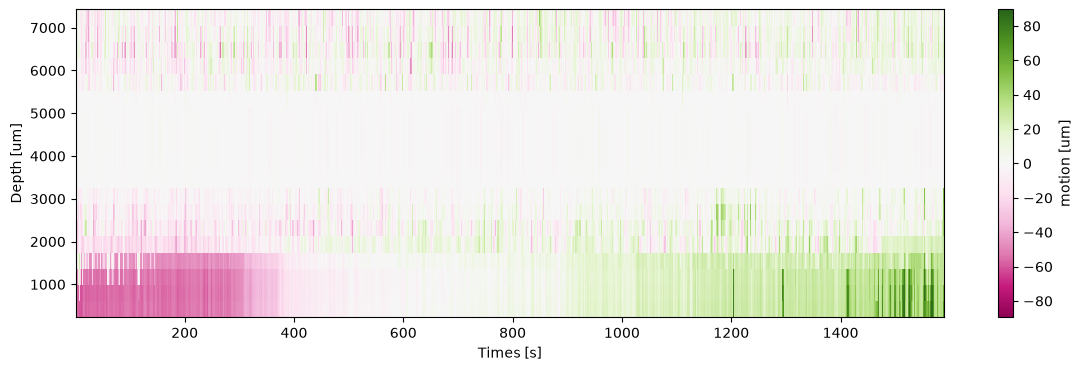

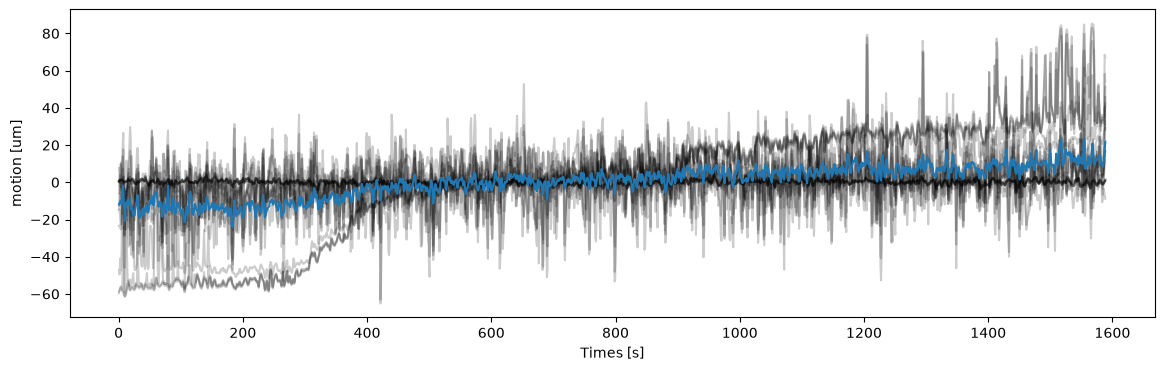

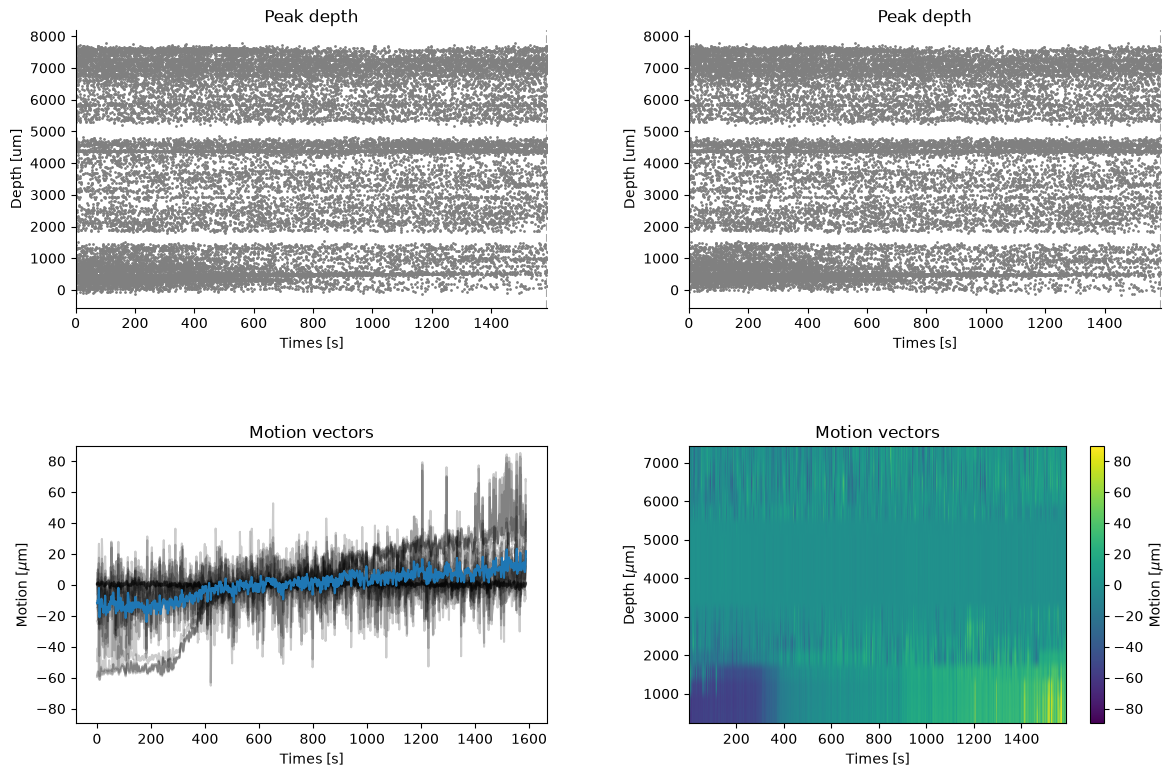

In [11]:
si.plot_motion(motion, mode="map", backend="matplotlib", figsize=(14, 4))
plt.show()

si.plot_motion(motion, mode="line", backend="matplotlib", figsize=(14, 4))
plt.show()

si.plot_motion_info(
    motion_info,
    recording=recording_for_motion,
    backend="matplotlib",
    scatter_decimate=20,
    color_amplitude=False,
    figsize=(14, 9),
)
plt.show()

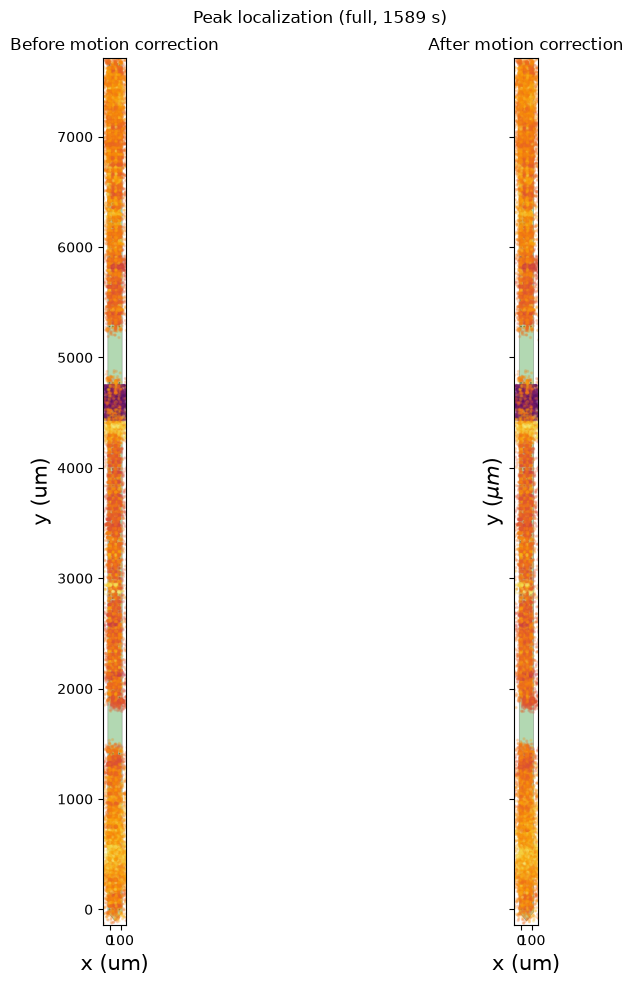

In [12]:
corrected_peak_locations = correct_motion_on_peaks(
    peaks,
    peak_locations,
    motion,
    recording_for_motion,
)

segment_index = 0
peak_mask = np.ones(peaks.shape[0], dtype=bool)
if "segment_index" in peaks.dtype.names:
    peak_mask &= peaks["segment_index"] == segment_index

masked_peak_indices = np.flatnonzero(peak_mask)
plot_step = max(1, masked_peak_indices.size // 50_000)
peak_plot_indices = masked_peak_indices[::plot_step]

peak_amplitudes = np.abs(peaks["amplitude"][peak_plot_indices])
amplitude_q95 = np.quantile(peak_amplitudes, 0.95)
scaled_amplitudes = peak_amplitudes / amplitude_q95 if amplitude_q95 > 0 else peak_amplitudes
peak_colors = plt.get_cmap("inferno")(np.clip(scaled_amplitudes, 0, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
for ax, locations, title in zip(
    axes,
    [peak_locations, corrected_peak_locations],
    ["Before motion correction", "After motion correction"],
):
    si.plot_probe_map(recording_for_motion, ax=ax)
    ax.scatter(
        locations["x"][peak_plot_indices],
        locations["y"][peak_plot_indices],
        s=2,
        alpha=0.2,
        c=peak_colors,
    )
    ax.set_title(title)
    ax.set_xlabel("x (um)")
axes[0].set_ylabel("y (um)")
fig.suptitle(f"Peak localization ({RUN_MODE}, {analysis_duration_s:.0f} s)")
fig.tight_layout()
plt.show()

In [13]:
CLUSTER_BIN_UM = 60.0
ZOOM_HALF_HEIGHT_UM = 180.0
MIN_CLUSTER_SEPARATION_UM = 250.0
NUM_ZOOM_CLUSTERS = 5

peak_depths_for_density = peak_locations["y"][peak_mask]
peak_depths_for_density = peak_depths_for_density[np.isfinite(peak_depths_for_density)]
density_y_min, density_y_max = np.nanpercentile(peak_depths_for_density, [0.5, 99.5])
density_bins = np.arange(density_y_min, density_y_max + CLUSTER_BIN_UM, CLUSTER_BIN_UM)
density_counts, density_edges = np.histogram(peak_depths_for_density, bins=density_bins)
density_centers = 0.5 * (density_edges[:-1] + density_edges[1:])

zoom_cluster_centers = []
for candidate_index in np.argsort(density_counts)[::-1]:
    if density_counts[candidate_index] == 0:
        break
    candidate_center = density_centers[candidate_index]
    if all(
        abs(candidate_center - existing_center) >= MIN_CLUSTER_SEPARATION_UM
        for existing_center in zoom_cluster_centers
    ):
        zoom_cluster_centers.append(candidate_center)
    if len(zoom_cluster_centers) >= NUM_ZOOM_CLUSTERS:
        break

zoom_cluster_centers = np.asarray(sorted(zoom_cluster_centers))
assert zoom_cluster_centers.size > 0, "No peak-dense depth bands were found."
print("Peak-dense depth centers (um):", np.round(zoom_cluster_centers, 1))

Peak-dense depth centers (um): [ 484.6 4384.6 6904.6 7264.6 7564.6]


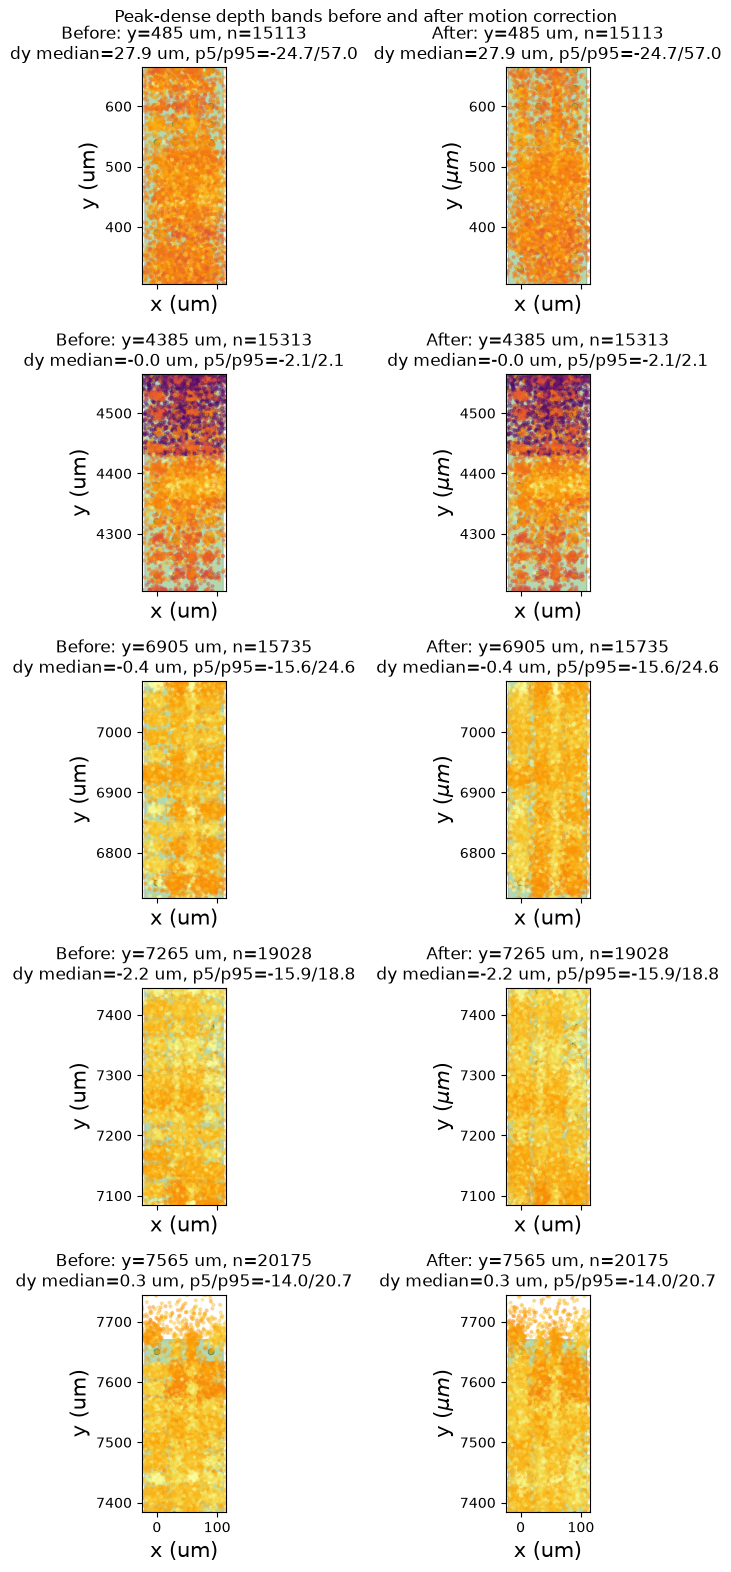

In [14]:
channel_locations = recording_for_motion.get_channel_locations()
plot_x_min = np.nanmin(channel_locations[:, 0]) - 25
plot_x_max = np.nanmax(channel_locations[:, 0]) + 25

fig, axes = plt.subplots(
    nrows=zoom_cluster_centers.size,
    ncols=2,
    figsize=(9, 3.2 * zoom_cluster_centers.size),
    sharex=True,
)
if zoom_cluster_centers.size == 1:
    axes = np.asarray([axes])

for row_index, depth_center in enumerate(zoom_cluster_centers):
    zoom_y_min = depth_center - ZOOM_HALF_HEIGHT_UM
    zoom_y_max = depth_center + ZOOM_HALF_HEIGHT_UM
    zoom_mask = (
        peak_mask
        & (peak_locations["y"] >= zoom_y_min)
        & (peak_locations["y"] <= zoom_y_max)
    )
    zoom_indices_all = np.flatnonzero(zoom_mask)
    zoom_step = max(1, zoom_indices_all.size // 15_000)
    zoom_indices = zoom_indices_all[::zoom_step]

    depth_shift = corrected_peak_locations["y"][zoom_indices] - peak_locations["y"][zoom_indices]
    median_shift = np.nanmedian(depth_shift) if depth_shift.size else np.nan
    shift_p5, shift_p95 = (
        np.nanpercentile(depth_shift, [5, 95]) if depth_shift.size else (np.nan, np.nan)
    )

    zoom_amplitudes = np.abs(peaks["amplitude"][zoom_indices])
    zoom_q95 = np.quantile(zoom_amplitudes, 0.95) if zoom_amplitudes.size else np.nan
    zoom_scaled = (
        zoom_amplitudes / zoom_q95
        if np.isfinite(zoom_q95) and zoom_q95 > 0
        else zoom_amplitudes
    )
    zoom_colors = plt.get_cmap("inferno")(np.clip(zoom_scaled, 0, 1))

    for ax, locations, title in zip(
        axes[row_index],
        [peak_locations, corrected_peak_locations],
        ["Before", "After"],
    ):
        si.plot_probe_map(recording_for_motion, ax=ax)
        ax.scatter(
            locations["x"][zoom_indices],
            locations["y"][zoom_indices],
            s=4,
            alpha=0.35,
            c=zoom_colors,
        )
        ax.set_xlim(plot_x_min, plot_x_max)
        ax.set_ylim(zoom_y_min, zoom_y_max)
        ax.set_title(
            f"{title}: y={depth_center:.0f} um, n={zoom_indices.size}\n"
            f"dy median={median_shift:.1f} um, p5/p95={shift_p5:.1f}/{shift_p95:.1f}"
        )
        ax.set_xlabel("x (um)")
    axes[row_index, 0].set_ylabel("y (um)")

fig.suptitle("Peak-dense depth bands before and after motion correction")
fig.tight_layout()
plt.show()

In [15]:
displacement_values = np.concatenate(
    [np.asarray(segment_displacement).ravel() for segment_displacement in motion.displacement]
)
assert np.all(np.isfinite(displacement_values))

final_summary = {
    "recording_id": SELECTED_RECORDING_ID,
    "run_mode": RUN_MODE,
    "analysis_duration_s": analysis_duration_s,
    "original_channels": recording.get_num_channels(),
    "removed_channels": int(dead_channel_ids.size),
    "retained_channels": recording_clean.get_num_channels(),
    "n_peaks": int(peaks.shape[0]),
    "displacement_min_um": float(np.min(displacement_values)),
    "displacement_max_um": float(np.max(displacement_values)),
    "computed_new_run": computed_new_run,
    "run_folder": str(run_folder),
}

print(json.dumps(final_summary, indent=2))

{
  "recording_id": "30Connell_1",
  "run_mode": "full",
  "analysis_duration_s": 1589.0,
  "original_channels": 1024,
  "removed_channels": 140,
  "retained_channels": 884,
  "n_peaks": 633207,
  "displacement_min_um": -65.14499462679962,
  "displacement_max_um": 85.34885931094495,
  "computed_new_run": false,
  "run_folder": "D:\\SPIHackerthon\\spikeinterface\\motion_outputs\\30Connell_1\\full_dredge_clean_bandpass_30um_v1"
}


# Kilosort4 full sorting

Kilosort4 performs its own AP preprocessing, common-average reference, whitening, and five-block
non-rigid drift correction. The previously validated SpikeInterface-DREDge motion is **not** applied
to the traces; it remains an independent reference for the post-sort drift comparison.

The sorter reads the original 1024-channel `int16` binary directly. Low-STD channels are passed as
Kilosort `bad_channels`, avoiding a channel-sliced float32 binary copy. This section remains disabled
until the raw data, selected motion run, and output root are all on storage outside the blocked SSD.

In [ ]:
import shutil

import pandas as pd

SORTER_NAME = "kilosort4"
KILOSORT4_OVERRIDES = {
    "nblocks": 5,
    "do_correction": True,
    "torch_device": "cuda",
    "keep_good_only": False,
    "use_binary_file": True,
    "save_preprocessed_copy": False,
    "delete_recording_dat": True,
}
ANALYZER_JOB_KWARGS = {
    "n_jobs": 8,
    "chunk_duration": "1s",
    "progress_bar": True,
}
ANALYZER_SPARSITY_RADIUS_UM = 100.0
RANDOM_SPIKES_PER_UNIT = 500

QC_METRIC_NAMES = [
    "num_spikes",
    "firing_rate",
    "presence_ratio",
    "snr",
    "isi_violation",
    "rp_violation",
    "amplitude_cv",
    "amplitude_cutoff",
    "amplitude_median",
    "drift",
    "sd_ratio",
    "nearest_neighbor",
    "silhouette",
    "d_prime",
]
QC_THRESHOLDS = {
    "min_num_spikes": 500,
    "min_snr": 5.0,
    "min_presence_ratio": 0.9,
    "max_amplitude_cutoff": 0.1,
    "max_rp_contamination": 0.2,
}
REDUNDANT_UNIT_PARAMS = {
    "align": True,
    "delta_time": 0.4,
    "agreement_threshold": 0.2,
    "duplicate_threshold": 0.8,
    "remove_strategy": "minimum_shift",
}


def to_jsonable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.generic):
        return to_jsonable(value.item())
    if isinstance(value, float) and not np.isfinite(value):
        return str(value)
    if isinstance(value, dict):
        return {str(key): to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    if isinstance(value, set):
        return sorted(to_jsonable(item) for item in value)
    return value


resolved_kilosort4_params = si.get_default_sorter_params(SORTER_NAME) | KILOSORT4_OVERRIDES

print(
    json.dumps(
        {
            "run_sorting_and_qc": RUN_SORTING_AND_QC,
            "confirm_healthy_storage": CONFIRM_HEALTHY_STORAGE,
            "sorting_output_root": to_jsonable(SORTING_OUTPUT_ROOT),
            "sorting_run_id": SORTING_RUN_ID,
            "sorter": SORTER_NAME,
            "kilosort4_overrides": KILOSORT4_OVERRIDES,
            "qc_metrics": QC_METRIC_NAMES,
            "qc_thresholds": QC_THRESHOLDS,
        },
        indent=2,
    )
)

In [ ]:
def nearest_existing_parent(path):
    candidate = Path(path).expanduser().resolve()
    while not candidate.exists():
        if candidate.parent == candidate:
            raise FileNotFoundError(f"No existing parent found for {path}")
        candidate = candidate.parent
    return candidate


def normalize_disk_serial(serial):
    return "".join(str(serial).upper().split())


def get_windows_disk_identity(path):
    anchor = nearest_existing_parent(path)
    drive_letter = anchor.drive.rstrip(":")
    if len(drive_letter) != 1:
        raise RuntimeError(f"Expected a local Windows drive for {path}; found {anchor.drive!r}.")

    powershell_script = (
        f"$partition = Get-Partition -DriveLetter '{drive_letter}'; "
        "$disk = Get-Disk -Number $partition.DiskNumber; "
        "[pscustomobject]@{"
        "DiskNumber=$disk.Number; "
        "FriendlyName=$disk.FriendlyName; "
        "SerialNumber=$disk.SerialNumber; "
        "HealthStatus=[string]$disk.HealthStatus; "
        "OperationalStatus=[string]$disk.OperationalStatus"
        "} | ConvertTo-Json -Compress"
    )
    completed = subprocess.run(
        ["powershell", "-NoProfile", "-Command", powershell_script],
        check=True,
        capture_output=True,
        text=True,
    )
    identity = json.loads(completed.stdout)
    identity["SerialNumberNormalized"] = normalize_disk_serial(identity["SerialNumber"])
    identity["AnchorPath"] = str(anchor)
    return identity


def run_sorting_storage_preflight():
    if not CONFIRM_HEALTHY_STORAGE:
        raise RuntimeError(
            "CONFIRM_HEALTHY_STORAGE is False. Do not run Kilosort4 until data and outputs are on a "
            "verified healthy physical disk."
        )
    if SORTING_OUTPUT_ROOT is None:
        raise RuntimeError("Set SORTING_OUTPUT_ROOT to a healthy physical disk before sorting.")
    if not dat_path.is_file():
        raise FileNotFoundError(dat_path)
    if not motion_folder.is_dir():
        raise FileNotFoundError(
            f"The selected SI-DREDge reference run is missing: {motion_folder}. "
            "Copy it to MOTION_OUTPUT_ROOT before sorting."
        )

    output_root = Path(SORTING_OUTPUT_ROOT).expanduser().resolve()
    path_identities = {
        "raw_data": get_windows_disk_identity(dat_path),
        "motion_reference": get_windows_disk_identity(motion_folder),
        "sorting_output": get_windows_disk_identity(output_root),
    }
    blocked_serials = {normalize_disk_serial(serial) for serial in UNSAFE_DISK_SERIALS}
    for role, identity in path_identities.items():
        if identity["SerialNumberNormalized"] in blocked_serials:
            raise RuntimeError(
                f"{role} is on blocked disk {identity['FriendlyName']} "
                f"(serial {identity['SerialNumber']})."
            )
        if identity["HealthStatus"].lower() != "healthy":
            raise RuntimeError(f"{role} disk is not Healthy: {identity}")

    output_anchor = nearest_existing_parent(output_root)
    free_space_gib = shutil.disk_usage(output_anchor).free / (1024**3)
    if free_space_gib < MIN_SORTING_FREE_SPACE_GIB:
        raise RuntimeError(
            f"Sorting output has only {free_space_gib:.1f} GiB free; "
            f"at least {MIN_SORTING_FREE_SPACE_GIB:.1f} GiB is required."
        )

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is required for this Kilosort4 configuration.")
    if SORTER_NAME not in si.installed_sorters():
        raise RuntimeError(f"{SORTER_NAME!r} is not installed in this kernel.")
    if np.dtype(recording_raw.get_dtype()) != np.dtype("int16"):
        raise RuntimeError(f"Kilosort4 source must remain int16, found {recording_raw.get_dtype()}.")
    if not recording_raw.binary_compatible_with(time_axis=0, file_paths_length=1):
        raise RuntimeError(
            "recording_raw is no longer directly binary-compatible; refusing to create a large copy."
        )

    return {
        "output_root": output_root,
        "free_space_gib": free_space_gib,
        "disk_identities": path_identities,
        "cuda_device": torch.cuda.get_device_name(0),
    }


storage_preflight = None
if RUN_SORTING_AND_QC:
    storage_preflight = run_sorting_storage_preflight()
    print(json.dumps(to_jsonable(storage_preflight), indent=2))
else:
    print("Kilosort4/QC disabled: storage preflight and all heavy stages were skipped.")

In [ ]:
kilosort_sorting = None
sorting_run_folder = None
sorter_folder = None
sorter_output_folder = None
analyzer_folder = None
qc_folder = None
sorting_fingerprint = None

if RUN_SORTING_AND_QC:
    raw_channel_ids = np.asarray(recording_raw.get_channel_ids())
    bad_channel_indices = np.asarray(
        recording_raw.ids_to_indices(dead_channel_ids),
        dtype="int64",
    )
    assert bad_channel_indices.size == dead_channel_ids.size
    assert np.array_equal(raw_channel_ids[bad_channel_indices], dead_channel_ids)

    sorter_params_for_run = resolved_kilosort4_params | {
        "bad_channels": bad_channel_indices.tolist(),
    }
    raw_file_stat = dat_path.stat()
    sorting_config = {
        "recording_id": SELECTED_RECORDING_ID,
        "run_mode": RUN_MODE,
        "sorting_run_id": SORTING_RUN_ID,
        "sorter_name": SORTER_NAME,
        "sorter_version": importlib.metadata.version("kilosort"),
        "spikeinterface_version": spikeinterface.__version__,
        "sorter_params": sorter_params_for_run,
        "bad_channel_ids": dead_channel_ids.tolist(),
        "bad_channel_indices": bad_channel_indices.tolist(),
        "probe_geometry_hash": probe_geometry_hash,
        "motion_reference_folder": str(motion_folder),
        "motion_config_fingerprint": config_fingerprint,
        "qc_metrics": QC_METRIC_NAMES,
        "qc_thresholds": QC_THRESHOLDS,
        "redundant_unit_params": REDUNDANT_UNIT_PARAMS,
        "data_identity": {
            "path": str(dat_path),
            "size_bytes": raw_file_stat.st_size,
            "mtime_ns": raw_file_stat.st_mtime_ns,
        },
    }
    sorting_fingerprint = hashlib.sha256(
        json.dumps(
            to_jsonable(sorting_config),
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()

    sorting_run_folder = (
        storage_preflight["output_root"]
        / SELECTED_RECORDING_ID
        / f"{RUN_MODE}_{SORTING_RUN_ID}"
    )
    sorter_folder = sorting_run_folder / "sorter"
    sorter_output_folder = sorter_folder / "sorter_output"
    analyzer_folder = sorting_run_folder / "sorting_analyzer"
    qc_folder = sorting_run_folder / "qc"
    provenance_path_sorting = sorting_run_folder / "provenance.json"
    sorting_complete_path = sorting_run_folder / "sorting_complete.json"

    if sorting_run_folder.exists():
        if not REUSE_EXISTING_SORTING:
            raise FileExistsError(
                f"Sorting run exists: {sorting_run_folder}. Choose a new SORTING_RUN_ID or enable reuse."
            )
        if not sorting_complete_path.is_file() or not sorter_output_folder.is_dir():
            raise RuntimeError(
                f"Incomplete sorting run will not be reused or overwritten: {sorting_run_folder}"
            )
        stored_completion = json.loads(sorting_complete_path.read_text(encoding="utf-8"))
        assert stored_completion["sorting_fingerprint"] == sorting_fingerprint
        kilosort_sorting = si.read_kilosort(sorter_output_folder, keep_good_only=False)
        print("Reused Kilosort4 sorting:", sorter_output_folder)
    else:
        sorting_run_folder.mkdir(parents=True, exist_ok=False)
        initial_sorting_provenance = {
            "status": "running",
            "created_at_utc": datetime.now(timezone.utc).isoformat(),
            "sorting_fingerprint": sorting_fingerprint,
            "environment": environment_info,
            "storage_preflight": storage_preflight,
            "sorting_config": sorting_config,
        }
        provenance_path_sorting.write_text(
            json.dumps(to_jsonable(initial_sorting_provenance), indent=2),
            encoding="utf-8",
        )

        try:
            kilosort_sorting = si.run_sorter(
                SORTER_NAME,
                recording_raw,
                folder=sorter_folder,
                remove_existing_folder=False,
                verbose=True,
                **sorter_params_for_run,
            )
        except BaseException as error:
            failed_provenance = initial_sorting_provenance | {
                "status": "failed",
                "failed_at_utc": datetime.now(timezone.utc).isoformat(),
                "error_type": type(error).__name__,
                "error_message": str(error),
            }
            provenance_path_sorting.write_text(
                json.dumps(to_jsonable(failed_provenance), indent=2),
                encoding="utf-8",
            )
            raise

        unit_ids = list(kilosort_sorting.get_unit_ids())
        if not unit_ids:
            raise RuntimeError("Kilosort4 completed but returned zero units.")
        total_spikes = sum(
            kilosort_sorting.get_unit_spike_train(unit_id=unit_id, segment_index=0).size
            for unit_id in unit_ids
        )
        sorting_completion = {
            "status": "complete",
            "completed_at_utc": datetime.now(timezone.utc).isoformat(),
            "sorting_fingerprint": sorting_fingerprint,
            "num_units": len(unit_ids),
            "num_spikes": int(total_spikes),
            "sorter_output_folder": str(sorter_output_folder),
        }
        sorting_complete_path.write_text(
            json.dumps(to_jsonable(sorting_completion), indent=2),
            encoding="utf-8",
        )
        completed_provenance = initial_sorting_provenance | sorting_completion
        provenance_path_sorting.write_text(
            json.dumps(to_jsonable(completed_provenance), indent=2),
            encoding="utf-8",
        )
        print("Completed Kilosort4 sorting:", sorter_output_folder)

    print(kilosort_sorting)
    print("units:", kilosort_sorting.get_num_units())

# Post-sorting quality control

QC is descriptive and conservative. The raw Kilosort output remains intact. A unit is marked
`candidate_good` only when its Kilosort label and every configured core threshold pass; all other
units are `needs_review`. Missing values fail the candidate screen. Duplicate-unit detection produces
a report only and never applies the returned filtered sorting.

Principal-component isolation metrics are intentionally limited to nearest-neighbor, silhouette, and
d-prime. The analyzer is sparse and disk-backed so its inputs, computed extensions, parameters, and
provenance remain inspectable after the notebook finishes.

In [ ]:
sorting_analyzer = None

if RUN_SORTING_AND_QC:
    analyzer_complete_path = sorting_run_folder / "analyzer_complete.json"

    if analyzer_folder.exists():
        if not analyzer_complete_path.is_file():
            raise RuntimeError(
                f"Incomplete analyzer folder will not be silently reused: {analyzer_folder}"
            )
        analyzer_completion = json.loads(analyzer_complete_path.read_text(encoding="utf-8"))
        assert analyzer_completion["sorting_fingerprint"] == sorting_fingerprint
        sorting_analyzer = si.load_sorting_analyzer(analyzer_folder)
        print("Reused SortingAnalyzer:", analyzer_folder)
    else:
        sorting_analyzer = si.create_sorting_analyzer(
            sorting=kilosort_sorting,
            recording=recording_clean_raw,
            format="binary_folder",
            folder=analyzer_folder,
            sparse=True,
            sparsity_kwargs={
                "method": "radius",
                "radius_um": ANALYZER_SPARSITY_RADIUS_UM,
            },
            return_in_uV=True,
            overwrite=False,
            seed=0,
            **ANALYZER_JOB_KWARGS,
        )
        sorting_analyzer.compute(
            "random_spikes",
            max_spikes_per_unit=RANDOM_SPIKES_PER_UNIT,
            seed=0,
        )
        sorting_analyzer.compute(
            "waveforms",
            ms_before=1.5,
            ms_after=2.5,
            **ANALYZER_JOB_KWARGS,
        )
        sorting_analyzer.compute(["templates", "noise_levels"])
        sorting_analyzer.compute("spike_amplitudes", **ANALYZER_JOB_KWARGS)
        sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
        sorting_analyzer.compute(
            "spike_locations",
            method="monopolar_triangulation",
            **ANALYZER_JOB_KWARGS,
        )
        sorting_analyzer.compute("correlograms", window_ms=100.0, bin_ms=1.0)
        sorting_analyzer.compute(
            "principal_components",
            n_components=5,
            mode="by_channel_local",
            **ANALYZER_JOB_KWARGS,
        )
        sorting_analyzer.compute("template_similarity")
        sorting_analyzer.compute("template_metrics")
        sorting_analyzer.compute(
            "quality_metrics",
            metric_names=QC_METRIC_NAMES,
            skip_pc_metrics=False,
            seed=0,
        )

        analyzer_completion = {
            "status": "complete",
            "completed_at_utc": datetime.now(timezone.utc).isoformat(),
            "sorting_fingerprint": sorting_fingerprint,
            "extensions": sorting_analyzer.get_loaded_extension_names(),
            "sparsity_radius_um": ANALYZER_SPARSITY_RADIUS_UM,
            "random_spikes_per_unit": RANDOM_SPIKES_PER_UNIT,
            "job_kwargs": ANALYZER_JOB_KWARGS,
        }
        analyzer_complete_path.write_text(
            json.dumps(to_jsonable(analyzer_completion), indent=2),
            encoding="utf-8",
        )
        print("Completed SortingAnalyzer:", analyzer_folder)

    print(sorting_analyzer)

In [ ]:
kilosort_motion_comparison = None
kilosort_motion_summary = None


def finite_correlation(first, second):
    finite = np.isfinite(first) & np.isfinite(second)
    if finite.sum() < 3 or np.std(first[finite]) == 0 or np.std(second[finite]) == 0:
        return np.nan
    return float(np.corrcoef(first[finite], second[finite])[0, 1])


def compare_kilosort_and_si_motion(ops, si_motion):
    dshift = np.asarray(ops.get("dshift"), dtype=float)
    block_depths_um = np.asarray(ops.get("yblk"), dtype=float)
    if dshift.ndim != 2 or block_depths_um.ndim != 1:
        raise RuntimeError("Kilosort ops does not contain a two-dimensional dshift and yblk vector.")
    if dshift.shape[1] != block_depths_um.size:
        raise RuntimeError(
            f"Kilosort dshift/yblk mismatch: {dshift.shape} versus {block_depths_um.shape}."
        )

    sampling_frequency_ks = float(ops["fs"])
    batch_size_samples = int(ops.get("batch_size", ops.get("NT")))
    tmin_s = float(ops.get("tmin", 0.0))
    batch_times_s = (
        np.arange(dshift.shape[0], dtype=float) * batch_size_samples / sampling_frequency_ks + tmin_s
    )
    si_displacement = si_motion.get_displacement_at_time_and_depth(
        batch_times_s,
        block_depths_um,
        segment_index=0,
        grid=True,
    ).T

    ks_centered = dshift - np.nanmedian(dshift, axis=0, keepdims=True)
    si_centered = si_displacement - np.nanmedian(si_displacement, axis=0, keepdims=True)
    sign_mae = {}
    for sign in (-1.0, 1.0):
        difference = sign * ks_centered - si_centered
        sign_mae[sign] = float(np.nanmean(np.abs(difference)))
    selected_sign = min(sign_mae, key=sign_mae.get)
    ks_aligned = selected_sign * ks_centered
    residual = ks_aligned - si_centered

    rows = []
    block_summaries = []
    for block_index, block_depth_um in enumerate(block_depths_um):
        block_residual = residual[:, block_index]
        block_summaries.append(
            {
                "block_index": block_index,
                "block_depth_um": float(block_depth_um),
                "correlation": finite_correlation(
                    ks_aligned[:, block_index],
                    si_centered[:, block_index],
                ),
                "mae_um": float(np.nanmean(np.abs(block_residual))),
                "rmse_um": float(np.sqrt(np.nanmean(block_residual**2))),
                "kilosort_peak_to_peak_um": float(
                    np.nanmax(ks_aligned[:, block_index]) - np.nanmin(ks_aligned[:, block_index])
                ),
                "si_peak_to_peak_um": float(
                    np.nanmax(si_centered[:, block_index]) - np.nanmin(si_centered[:, block_index])
                ),
            }
        )
        for time_index, time_s in enumerate(batch_times_s):
            rows.append(
                {
                    "time_s": float(time_s),
                    "block_index": block_index,
                    "block_depth_um": float(block_depth_um),
                    "kilosort_displacement_centered_um": float(ks_aligned[time_index, block_index]),
                    "si_displacement_centered_um": float(si_centered[time_index, block_index]),
                    "residual_um": float(residual[time_index, block_index]),
                }
            )

    summary = {
        "kilosort_sign_applied": selected_sign,
        "sign_mae_um": {str(sign): value for sign, value in sign_mae.items()},
        "overall_correlation": finite_correlation(ks_aligned.ravel(), si_centered.ravel()),
        "overall_mae_um": float(np.nanmean(np.abs(residual))),
        "overall_rmse_um": float(np.sqrt(np.nanmean(residual**2))),
        "num_time_bins": int(dshift.shape[0]),
        "num_depth_blocks": int(dshift.shape[1]),
        "blocks": block_summaries,
    }
    return pd.DataFrame(rows), summary


if RUN_SORTING_AND_QC:
    ops_path = sorter_output_folder / "ops.npy"
    if not ops_path.is_file():
        raise FileNotFoundError(f"Kilosort ops.npy is missing: {ops_path}")
    kilosort_ops = np.load(ops_path, allow_pickle=True).item()
    kilosort_motion_comparison, kilosort_motion_summary = compare_kilosort_and_si_motion(
        kilosort_ops,
        motion,
    )

    qc_folder.mkdir(parents=True, exist_ok=True)
    kilosort_motion_comparison.to_csv(qc_folder / "kilosort_vs_si_motion.csv", index=False)
    (qc_folder / "kilosort_vs_si_motion_summary.json").write_text(
        json.dumps(to_jsonable(kilosort_motion_summary), indent=2),
        encoding="utf-8",
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, constrained_layout=True)
    for block_index, block_table in kilosort_motion_comparison.groupby("block_index"):
        depth_um = block_table["block_depth_um"].iloc[0]
        axes[0].plot(
            block_table["time_s"],
            block_table["kilosort_displacement_centered_um"],
            linewidth=0.8,
            label=f"KS block {block_index} ({depth_um:.0f} um)",
        )
        axes[1].plot(
            block_table["time_s"],
            block_table["si_displacement_centered_um"],
            linewidth=0.8,
            label=f"SI at {depth_um:.0f} um",
        )
    axes[0].set_title("Kilosort4 five-block drift (offset/sign aligned for comparison)")
    axes[1].set_title("SpikeInterface-DREDge displacement at matching depths/times")
    axes[1].set_xlabel("Time (s)")
    for ax in axes:
        ax.set_ylabel("Centered displacement (um)")
        ax.legend(ncol=2, fontsize=8)
    fig.savefig(qc_folder / "kilosort_vs_si_motion.png", dpi=180)
    plt.show()

    print(json.dumps(to_jsonable(kilosort_motion_summary), indent=2))

In [ ]:
quality_metrics = None
template_metrics = None
unit_qc_table = None
redundant_unit_pairs_table = None


def build_candidate_qc_table(quality_metrics_table, ks_labels, unit_depths_um):
    table = quality_metrics_table.copy()
    table["KSLabel"] = pd.Series(ks_labels, index=table.index).astype(str)
    table["unit_depth_um"] = pd.Series(unit_depths_um, index=table.index, dtype=float)

    table["pass_kslabel"] = table["KSLabel"].str.lower().eq("good")
    table["pass_num_spikes"] = table["num_spikes"].ge(QC_THRESHOLDS["min_num_spikes"]).fillna(False)
    table["pass_snr"] = table["snr"].ge(QC_THRESHOLDS["min_snr"]).fillna(False)
    table["pass_presence_ratio"] = table["presence_ratio"].ge(
        QC_THRESHOLDS["min_presence_ratio"]
    ).fillna(False)
    table["pass_amplitude_cutoff"] = table["amplitude_cutoff"].le(
        QC_THRESHOLDS["max_amplitude_cutoff"]
    ).fillna(False)
    table["pass_rp_contamination"] = table["rp_contamination"].le(
        QC_THRESHOLDS["max_rp_contamination"]
    ).fillna(False)

    pass_columns = [column for column in table.columns if column.startswith("pass_")]
    table["failed_criteria"] = (~table[pass_columns]).sum(axis=1)
    table["qc_label"] = np.where(
        table[pass_columns].all(axis=1),
        "candidate_good",
        "needs_review",
    )
    return table


if RUN_SORTING_AND_QC:
    quality_metrics = sorting_analyzer.get_extension("quality_metrics").get_data()
    template_metrics = sorting_analyzer.get_extension("template_metrics").get_data()
    unit_ids = np.asarray(kilosort_sorting.get_unit_ids())

    if "KSLabel" in kilosort_sorting.get_property_keys():
        ks_labels = kilosort_sorting.get_property("KSLabel")
    else:
        ks_labels = np.full(unit_ids.size, "unlabeled", dtype=object)

    unit_locations = np.asarray(sorting_analyzer.get_extension("unit_locations").get_data())
    if unit_locations.shape[0] != unit_ids.size or unit_locations.shape[1] < 2:
        raise RuntimeError(f"Unexpected unit-location shape: {unit_locations.shape}")
    unit_depths_um = pd.Series(unit_locations[:, 1], index=unit_ids)

    quality_metrics = quality_metrics.reindex(unit_ids)
    unit_qc_table = build_candidate_qc_table(
        quality_metrics,
        pd.Series(ks_labels, index=unit_ids),
        unit_depths_um,
    )
    unit_qc_table = unit_qc_table.join(template_metrics.add_prefix("template_"), how="left")

    _, redundant_unit_pairs = si.remove_redundant_units(
        sorting_analyzer,
        extra_outputs=True,
        **REDUNDANT_UNIT_PARAMS,
    )
    redundant_unit_pairs_table = pd.DataFrame(
        redundant_unit_pairs,
        columns=["unit_id_a", "unit_id_b"],
    )

    qc_folder.mkdir(parents=True, exist_ok=True)
    quality_metrics.to_csv(qc_folder / "quality_metrics.csv", index_label="unit_id")
    template_metrics.to_csv(qc_folder / "template_metrics.csv", index_label="unit_id")
    unit_qc_table.to_csv(qc_folder / "unit_qc_labels.csv", index_label="unit_id")
    redundant_unit_pairs_table.to_csv(qc_folder / "redundant_unit_candidates.csv", index=False)

    qc_completion = {
        "status": "complete",
        "completed_at_utc": datetime.now(timezone.utc).isoformat(),
        "sorting_fingerprint": sorting_fingerprint,
        "num_units": int(unit_qc_table.shape[0]),
        "num_candidate_good": int((unit_qc_table["qc_label"] == "candidate_good").sum()),
        "num_needs_review": int((unit_qc_table["qc_label"] == "needs_review").sum()),
        "num_redundant_candidate_pairs": int(redundant_unit_pairs_table.shape[0]),
        "qc_thresholds": QC_THRESHOLDS,
        "redundant_unit_params": REDUNDANT_UNIT_PARAMS,
    }
    (sorting_run_folder / "qc_complete.json").write_text(
        json.dumps(to_jsonable(qc_completion), indent=2),
        encoding="utf-8",
    )

    print(unit_qc_table["qc_label"].value_counts(dropna=False))
    print("Redundant-unit candidate pairs:", redundant_unit_pairs_table.shape[0])
    display(unit_qc_table)

In [ ]:
representative_unit_ids = []


def spread_across_depth(unit_table, count):
    if unit_table.empty or count <= 0:
        return []
    ordered = unit_table.sort_values(["unit_depth_um"], kind="stable")
    positions = np.linspace(0, ordered.shape[0] - 1, min(count, ordered.shape[0]))
    return ordered.index[np.unique(np.rint(positions).astype(int))].tolist()


def select_representative_units(qc_table, per_group=4):
    selected = []
    candidate = qc_table[qc_table["qc_label"] == "candidate_good"]
    selected.extend(spread_across_depth(candidate, per_group))

    remaining = qc_table.loc[~qc_table.index.isin(selected)].copy()
    remaining["unit_sort_key"] = remaining.index.map(str)
    borderline = remaining.sort_values(
        ["failed_criteria", "unit_sort_key"],
        ascending=[True, True],
        kind="stable",
    )
    selected.extend(borderline.index[:per_group].tolist())

    remaining = qc_table.loc[~qc_table.index.isin(selected)].copy()
    remaining["unit_sort_key"] = remaining.index.map(str)
    low_quality = remaining.sort_values(
        ["failed_criteria", "unit_sort_key"],
        ascending=[False, True],
        kind="stable",
    )
    selected.extend(low_quality.index[:per_group].tolist())
    return selected


if RUN_SORTING_AND_QC:
    representative_unit_ids = select_representative_units(unit_qc_table, per_group=4)
    (qc_folder / "representative_unit_ids.json").write_text(
        json.dumps(to_jsonable(representative_unit_ids), indent=2),
        encoding="utf-8",
    )

    metric_panels = [
        ("snr", QC_THRESHOLDS["min_snr"], "min"),
        ("presence_ratio", QC_THRESHOLDS["min_presence_ratio"], "min"),
        ("amplitude_cutoff", QC_THRESHOLDS["max_amplitude_cutoff"], "max"),
        ("rp_contamination", QC_THRESHOLDS["max_rp_contamination"], "max"),
        ("firing_rate", None, None),
        ("drift_ptp", None, None),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    for ax, (metric, threshold, direction) in zip(axes.flat, metric_panels):
        finite_values = unit_qc_table[metric].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(finite_values, bins=40, color="#287271", alpha=0.85)
        if threshold is not None:
            ax.axvline(threshold, color="#c23b22", linestyle="--", label=f"{direction} {threshold}")
            ax.legend()
        ax.set_title(metric)
        ax.set_ylabel("Units")
    fig.suptitle("Kilosort4 unit quality metrics")
    fig.savefig(qc_folder / "quality_metric_distributions.png", dpi=180)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 10), constrained_layout=True)
    candidate_mask = unit_qc_table["qc_label"] == "candidate_good"
    ax.scatter(
        unit_qc_table.loc[~candidate_mask, "snr"],
        unit_qc_table.loc[~candidate_mask, "unit_depth_um"],
        s=18,
        alpha=0.55,
        color="#7f8c8d",
        label="needs_review",
    )
    ax.scatter(
        unit_qc_table.loc[candidate_mask, "snr"],
        unit_qc_table.loc[candidate_mask, "unit_depth_um"],
        s=22,
        alpha=0.8,
        color="#d1495b",
        label="candidate_good",
    )
    ax.axvline(QC_THRESHOLDS["min_snr"], color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("SNR")
    ax.set_ylabel("Unit depth (um)")
    ax.set_title("Unit depth and conservative QC label")
    ax.legend()
    fig.savefig(qc_folder / "unit_depth_vs_snr.png", dpi=180)
    plt.show()

    spike_vector = kilosort_sorting.to_spike_vector()
    raster_step = max(1, spike_vector.size // 200_000)
    raster_spikes = spike_vector[::raster_step]
    unit_depth_array = unit_qc_table["unit_depth_um"].reindex(unit_ids).to_numpy()
    raster_depths = unit_depth_array[raster_spikes["unit_index"]]
    raster_times_s = raster_spikes["sample_index"] / sampling_frequency
    fig, ax = plt.subplots(figsize=(15, 7), constrained_layout=True)
    ax.scatter(raster_times_s, raster_depths, s=1, alpha=0.2, color="black", rasterized=True)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Unit depth (um)")
    ax.set_title(f"Full-recording unit raster (decimation 1:{raster_step})")
    fig.savefig(qc_folder / "unit_raster_by_depth.png", dpi=180)
    plt.show()

    if representative_unit_ids:
        si.plot_amplitudes(
            sorting_analyzer,
            unit_ids=representative_unit_ids,
            max_spikes_per_unit=2_000,
            backend="matplotlib",
            figsize=(14, 7),
        )
        plt.gcf().savefig(qc_folder / "representative_unit_amplitudes.png", dpi=180)
        plt.show()

    for unit_id in representative_unit_ids:
        si.plot_unit_summary(
            sorting_analyzer,
            unit_id=unit_id,
            backend="matplotlib",
        )
        safe_unit_id = str(unit_id).replace("/", "_").replace("\\", "_")
        plt.gcf().savefig(qc_folder / f"unit_summary_{safe_unit_id}.png", dpi=160)
        plt.show()

    print("Representative units:", representative_unit_ids)

In [ ]:
if RUN_SORTING_AND_QC:
    final_pipeline_summary = final_summary | {
        "sorter": SORTER_NAME,
        "sorting_run_id": SORTING_RUN_ID,
        "sorting_fingerprint": sorting_fingerprint,
        "sorting_run_folder": str(sorting_run_folder),
        "num_units": int(unit_qc_table.shape[0]),
        "num_candidate_good": int((unit_qc_table["qc_label"] == "candidate_good").sum()),
        "num_needs_review": int((unit_qc_table["qc_label"] == "needs_review").sum()),
        "num_redundant_candidate_pairs": int(redundant_unit_pairs_table.shape[0]),
        "kilosort_vs_si_motion": kilosort_motion_summary,
        "representative_unit_ids": representative_unit_ids,
    }
    (sorting_run_folder / "final_pipeline_summary.json").write_text(
        json.dumps(to_jsonable(final_pipeline_summary), indent=2),
        encoding="utf-8",
    )
    print(json.dumps(to_jsonable(final_pipeline_summary), indent=2))
else:
    print(
        "Pipeline code is ready, but full sorting/QC was intentionally not executed. "
        "Copy the raw data and selected motion run to healthy storage, update the selected dat_path and "
        "MOTION_OUTPUT_ROOT, set SORTING_OUTPUT_ROOT, "
        "then enable CONFIRM_HEALTHY_STORAGE and RUN_SORTING_AND_QC."
    )

# Full LUPIN with reused DREDge motion

This branch is independent of Kilosort4. It rebuilds the complete 30Connell_1 recording from a
verified copy on healthy storage, removes the exact 140 channels recorded in the completed DREDge
provenance, reproduces LUPIN's official preprocessing order, and applies that saved Motion object
before materializing a float32 binary recording.

LUPIN then receives the already preprocessed and motion-corrected binary with both internal
preprocessing and internal motion estimation disabled. No real-data pilot or smoke sorting is
introduced. Every write-heavy stage is opt-in, refuses C:, D:, E: and the known CF600 2TB disk,
and preserves incomplete output for inspection rather than deleting or overwriting it.

In [ ]:
import os
import pickle
import tempfile
import time

import pandas as pd
from spikeinterface.core import generate_ground_truth_recording
from spikeinterface.core.motion import Motion
from spikeinterface.sorters.internal.lupin import LupinSorter
from spikeinterface.sortingcomponents.motion import InterpolateMotionRecording

LUPIN_RECORDING_ID = "30Connell_1"
LUPIN_RUN_ID = "full_lupin_reused_dredge_v1"
LUPIN_MOTION_RUN_FOLDER = (
    PROJECT_ROOT
    / "motion_outputs"
    / LUPIN_RECORDING_ID
    / "full_dredge_clean_bandpass_30um_v1"
)

LUPIN_EXPECTED_RAW_CHANNELS = 1024
LUPIN_EXPECTED_RETAINED_CHANNELS = 884
LUPIN_EXPECTED_REMOVED_CHANNELS = 140
LUPIN_EXPECTED_FRAMES = 31_780_000
LUPIN_EXPECTED_SAMPLING_FREQUENCY = 20_000.0
LUPIN_EXPECTED_RAW_FILE_SIZE_BYTES = 65_085_440_000
LUPIN_EXPECTED_PROBE_GEOMETRY_HASH = (
    "90e7c131f0de6f390d7e46d73113de83f240d62f653ffbf7169aea20021a83c1"
)
LUPIN_EXPECTED_MOTION_CONFIG_FINGERPRINT = (
    "8fcc5fe53223185f75ec0483882f53adf11ea92a58c263ed6187703558155adc"
)
LUPIN_EXPECTED_MATERIALIZED_BYTES = (
    LUPIN_EXPECTED_FRAMES * LUPIN_EXPECTED_RETAINED_CHANNELS * np.dtype("float32").itemsize
)

LUPIN_BLOCKED_DRIVE_LETTERS = {"C", "D", "E"}
LUPIN_BLOCKED_FRIENDLY_NAMES = {"CF600 2TB"}
LUPIN_COPY_CHUNK_BYTES = 16 * 1024**2

LUPIN_PREPROCESSING_PARAMS = {
    "bandpass": {
        "freq_min": 150.0,
        "freq_max": 7000.0,
        "ftype": "bessel",
        "filter_order": 2,
        "dtype": "float32",
    },
    "common_reference": {
        "reference": "global",
        "operator": "median",
    },
    "whiten": {
        "dtype": "float32",
        "mode": "local",
        "radius_um": 100.0,
        "seed": LUPIN_SEED,
    },
}
LUPIN_INTERPOLATION_PARAMS = {
    "border_mode": "force_extrapolate",
    "spatial_interpolation_method": "kriging",
    "sigma_um": 20.0,
    "p": 2,
    "dtype": "float32",
}
LUPIN_MATERIALIZATION_JOB_KWARGS = {
    "n_jobs": 1,
    "chunk_duration": "1s",
    "progress_bar": True,
}
LUPIN_SORTER_OVERRIDES = {
    "apply_preprocessing": False,
    "apply_motion_correction": False,
    "cache_preprocessing_mode": "no-cache",
    "gather_mode": "npy",
    "save_array": True,
    "seed": LUPIN_SEED,
    "job_kwargs": {
        "n_jobs": 1,
        "chunk_duration": "1s",
    },
}
LUPIN_RESOLVED_SORTER_PARAMS = (
    si.get_default_sorter_params("lupin") | LUPIN_SORTER_OVERRIDES
)

assert LUPIN_RESOLVED_SORTER_PARAMS["template_matching_engine"] == "wobble"
assert LUPIN_RESOLVED_SORTER_PARAMS["apply_preprocessing"] is False
assert LUPIN_RESOLVED_SORTER_PARAMS["apply_motion_correction"] is False
assert LUPIN_RESOLVED_SORTER_PARAMS["gather_mode"] == "npy"
assert LUPIN_RESOLVED_SORTER_PARAMS["save_array"] is True

LUPIN_EXECUTION_REQUESTED = any(
    [
        RUN_LUPIN_MATERIALIZATION,
        RUN_LUPIN_SORTING,
        RUN_LUPIN_QC,
        RUN_LUPIN_SYNTHETIC_VALIDATION,
    ]
)

print(
    json.dumps(
        to_jsonable(
            {
                "storage_root": LUPIN_STORAGE_ROOT,
                "confirm_healthy_storage": CONFIRM_HEALTHY_LUPIN_STORAGE,
                "run_materialization": RUN_LUPIN_MATERIALIZATION,
                "run_sorting": RUN_LUPIN_SORTING,
                "run_qc": RUN_LUPIN_QC,
                "run_synthetic_validation": RUN_LUPIN_SYNTHETIC_VALIDATION,
                "motion_run_folder": LUPIN_MOTION_RUN_FOLDER,
                "expected_materialized_gib": LUPIN_EXPECTED_MATERIALIZED_BYTES / 1024**3,
                "sorter_version": LupinSorter.get_sorter_version(),
                "sorter_overrides": LUPIN_SORTER_OVERRIDES,
            }
        ),
        indent=2,
    )
)

## Storage preflight

The storage root must already exist on a local Windows physical disk. The preflight resolves every
derived path to that disk, checks health and free space, rejects the known failing disk by drive
letter, model, serial, and physical disk number, and confirms that the destination disk differs
from both the raw source and the project checkout. Merely setting a path is insufficient:
CONFIRM_HEALTHY_LUPIN_STORAGE must also be enabled.

In [ ]:
def lupin_canonical_fingerprint(payload):
    encoded = json.dumps(
        to_jsonable(payload),
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def lupin_sha256_file(path, chunk_bytes=LUPIN_COPY_CHUNK_BYTES):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        while True:
            block = stream.read(chunk_bytes)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def lupin_sha256_tree(folder, chunk_bytes=LUPIN_COPY_CHUNK_BYTES):
    folder = Path(folder).resolve()
    digest = hashlib.sha256()
    files = sorted(path for path in folder.rglob("*") if path.is_file())
    if not files:
        raise RuntimeError(f"Cannot fingerprint empty folder: {folder}")
    for path in files:
        relative_name = path.relative_to(folder).as_posix().encode("utf-8")
        digest.update(relative_name)
        digest.update(b"\0")
        with path.open("rb") as stream:
            while True:
                block = stream.read(chunk_bytes)
                if not block:
                    break
                digest.update(block)
    return digest.hexdigest()


def lupin_nearest_existing_parent(path):
    candidate = Path(path).expanduser().resolve()
    while not candidate.exists():
        if candidate.parent == candidate:
            raise FileNotFoundError(f"No existing parent found for {path}")
        candidate = candidate.parent
    return candidate


def lupin_normalize_disk_serial(serial):
    return "".join(str(serial).upper().split())


def lupin_normalize_disk_name(name):
    return " ".join(str(name).upper().split())


def lupin_get_windows_disk_identity(path):
    anchor = lupin_nearest_existing_parent(path)
    drive_letter = anchor.drive.rstrip(":").upper()
    if len(drive_letter) != 1:
        raise RuntimeError(
            f"LUPIN requires a local Windows physical disk; found {anchor.drive!r} for {path}."
        )

    powershell_script = (
        f"$partition = Get-Partition -DriveLetter '{drive_letter}' -ErrorAction Stop; "
        "$disk = Get-Disk -Number $partition.DiskNumber -ErrorAction Stop; "
        "[pscustomobject]@{"
        f"DriveLetter='{drive_letter}'; "
        "DiskNumber=[int]$disk.Number; "
        "FriendlyName=[string]$disk.FriendlyName; "
        "SerialNumber=[string]$disk.SerialNumber; "
        "HealthStatus=[string]$disk.HealthStatus; "
        "OperationalStatus=($disk.OperationalStatus -join ','); "
        "BusType=[string]$disk.BusType; "
        "SizeBytes=[int64]$disk.Size"
        "} | ConvertTo-Json -Compress"
    )
    completed = subprocess.run(
        ["powershell", "-NoProfile", "-Command", powershell_script],
        check=True,
        capture_output=True,
        text=True,
    )
    identity = json.loads(completed.stdout)
    identity["SerialNumberNormalized"] = lupin_normalize_disk_serial(
        identity["SerialNumber"]
    )
    identity["FriendlyNameNormalized"] = lupin_normalize_disk_name(
        identity["FriendlyName"]
    )
    identity["AnchorPath"] = str(anchor)
    return identity


def lupin_package_version(distribution_name):
    try:
        return importlib.metadata.version(distribution_name)
    except importlib.metadata.PackageNotFoundError:
        return None


def lupin_environment_versions():
    lupin_source_path = (
        PROJECT_ROOT
        / "src"
        / "spikeinterface"
        / "sorters"
        / "internal"
        / "lupin.py"
    )
    return {
        "python": sys.version,
        "platform": platform.platform(),
        "spikeinterface": spikeinterface.__version__,
        "probeinterface": probeinterface.__version__,
        "numpy": np.__version__,
        "scipy": lupin_package_version("scipy"),
        "numba": lupin_package_version("numba"),
        "scikit_learn": lupin_package_version("scikit-learn"),
        "torch": torch.__version__,
        "lupin": LupinSorter.get_sorter_version(),
        "lupin_source_sha256": lupin_sha256_file(lupin_source_path),
        "git_head": git_head,
    }


def lupin_derive_paths(storage_root):
    storage_root = Path(storage_root).expanduser().resolve()
    run_folder = (
        storage_root
        / "lupin_runs"
        / LUPIN_RECORDING_ID
        / LUPIN_RUN_ID
    )
    raw_copy_folder = storage_root / "raw_recordings" / LUPIN_RECORDING_ID
    return {
        "storage_root": storage_root,
        "raw_copy_folder": raw_copy_folder,
        "raw_copy_path": raw_copy_folder / "30Connell_1.dat",
        "raw_copy_manifest_path": raw_copy_folder / "raw_copy_manifest.json",
        "run_folder": run_folder,
        "materialized_folder": run_folder / "materialized_recording",
        "materialization_manifest_path": run_folder / "materialization_manifest.json",
        "sorter_folder": run_folder / "sorter",
        "sorting_provenance_path": run_folder / "sorting_provenance.json",
        "sorting_complete_path": run_folder / "sorting_complete.json",
        "analyzer_folder": run_folder / "sorting_analyzer",
        "analyzer_complete_path": run_folder / "analyzer_complete.json",
        "qc_folder": run_folder / "qc",
        "qc_provenance_path": run_folder / "qc_provenance.json",
        "qc_complete_path": run_folder / "qc_complete.json",
        "validation_root": storage_root / "lupin_synthetic_validation",
    }


def run_lupin_storage_preflight():
    if not CONFIRM_HEALTHY_LUPIN_STORAGE:
        raise RuntimeError(
            "CONFIRM_HEALTHY_LUPIN_STORAGE is False. LUPIN cannot write or sort."
        )
    if LUPIN_STORAGE_ROOT is None:
        raise RuntimeError("Set LUPIN_STORAGE_ROOT to an existing folder on a healthy disk.")
    if SELECTED_RECORDING_ID != LUPIN_RECORDING_ID or RUN_MODE != "full":
        raise RuntimeError(
            "This accepted LUPIN run is fixed to SELECTED_RECORDING_ID='30Connell_1' "
            "and RUN_MODE='full'."
        )

    storage_root = Path(LUPIN_STORAGE_ROOT).expanduser().resolve()
    if not storage_root.is_dir():
        raise FileNotFoundError(
            f"LUPIN_STORAGE_ROOT must already exist and be a directory: {storage_root}"
        )

    source_path = Path(RECORDINGS[LUPIN_RECORDING_ID]["dat_path"]).resolve()
    motion_info_folder = LUPIN_MOTION_RUN_FOLDER / "motion_info"
    motion_provenance_path = LUPIN_MOTION_RUN_FOLDER / "provenance.json"
    if not motion_info_folder.is_dir() or not motion_provenance_path.is_file():
        raise FileNotFoundError(
            f"Completed external DREDge motion is missing: {LUPIN_MOTION_RUN_FOLDER}"
        )

    motion_provenance = json.loads(
        motion_provenance_path.read_text(encoding="utf-8")
    )
    if motion_provenance.get("status") != "complete":
        raise RuntimeError("The selected DREDge provenance is not complete.")
    if (
        motion_provenance.get("config_fingerprint")
        != LUPIN_EXPECTED_MOTION_CONFIG_FINGERPRINT
    ):
        raise RuntimeError("The selected DREDge fingerprint is not the accepted full run.")

    paths = lupin_derive_paths(storage_root)
    stored_source = motion_provenance["data_identity"]
    source_identity = {
        "path": str(source_path),
        "size_bytes": stored_source["size_bytes"],
        "mtime_ns": stored_source["mtime_ns"],
    }
    raw_copy_manifest_ready = (
        paths["raw_copy_path"].is_file()
        and paths["raw_copy_manifest_path"].is_file()
    )
    if raw_copy_manifest_ready:
        raw_copy_manifest = json.loads(
            paths["raw_copy_manifest_path"].read_text(encoding="utf-8")
        )
        raw_copy_manifest_ready = (
            raw_copy_manifest.get("status") == "complete"
            and raw_copy_manifest.get("source_identity") == source_identity
        )

    source_disk_identity = None
    if source_path.is_file():
        source_stat = source_path.stat()
        if source_stat.st_size != LUPIN_EXPECTED_RAW_FILE_SIZE_BYTES:
            raise RuntimeError(
                f"Unexpected raw size: {source_stat.st_size}; "
                f"expected {LUPIN_EXPECTED_RAW_FILE_SIZE_BYTES}."
            )
        if source_stat.st_size != stored_source["size_bytes"]:
            raise RuntimeError("Raw source size differs from DREDge provenance.")
        if source_stat.st_mtime_ns != stored_source["mtime_ns"]:
            raise RuntimeError("Raw source mtime differs from DREDge provenance.")
        source_disk_identity = lupin_get_windows_disk_identity(source_path)
    elif not raw_copy_manifest_ready:
        raise FileNotFoundError(
            f"Raw source is unavailable and no complete healthy-disk copy exists: {source_path}"
        )
    else:
        print(
            "Original raw source is offline; continuing from the complete verified "
            "healthy-disk copy."
        )
    target_paths = {
        "storage_root": paths["storage_root"],
        "raw_copy": paths["raw_copy_path"],
        "materialized_recording": paths["materialized_folder"],
        "sorter_output": paths["sorter_folder"],
        "sorting_analyzer": paths["analyzer_folder"],
    }
    target_identities = {
        role: lupin_get_windows_disk_identity(path)
        for role, path in target_paths.items()
    }
    blocked_serials = {
        lupin_normalize_disk_serial(serial) for serial in UNSAFE_DISK_SERIALS
    }
    blocked_names = {
        lupin_normalize_disk_name(name) for name in LUPIN_BLOCKED_FRIENDLY_NAMES
    }
    for role, identity in target_identities.items():
        if identity["DriveLetter"] in LUPIN_BLOCKED_DRIVE_LETTERS:
            raise RuntimeError(
                f"{role} resolves to blocked drive {identity['DriveLetter']}:."
            )
        if identity["SerialNumberNormalized"] in blocked_serials:
            raise RuntimeError(
                f"{role} resolves to blocked disk serial {identity['SerialNumber']}."
            )
        if identity["FriendlyNameNormalized"] in blocked_names:
            raise RuntimeError(
                f"{role} resolves to blocked disk model {identity['FriendlyName']}."
            )
        if identity["HealthStatus"].lower() != "healthy":
            raise RuntimeError(f"{role} disk is not Healthy: {identity}")
        if "online" not in identity["OperationalStatus"].lower():
            raise RuntimeError(f"{role} disk is not Online: {identity}")

    target_disk_numbers = {
        int(identity["DiskNumber"]) for identity in target_identities.values()
    }
    if len(target_disk_numbers) != 1:
        raise RuntimeError(
            f"LUPIN raw copy, materialization, sorter, and analyzer must share one "
            f"verified physical disk; found {target_disk_numbers}."
        )
    target_disk_number = next(iter(target_disk_numbers))

    project_disk_identity = lupin_get_windows_disk_identity(PROJECT_ROOT)
    if (
        source_disk_identity is not None
        and target_disk_number == int(source_disk_identity["DiskNumber"])
    ):
        raise RuntimeError("LUPIN storage is on the same physical disk as the raw source.")
    if target_disk_number == int(project_disk_identity["DiskNumber"]):
        raise RuntimeError("LUPIN storage is on the same physical disk as the project checkout.")

    free_space_gib = shutil.disk_usage(storage_root).free / 1024**3
    if free_space_gib < LUPIN_MIN_FREE_SPACE_GIB:
        raise RuntimeError(
            f"LUPIN storage has only {free_space_gib:.1f} GiB free; "
            f"at least {LUPIN_MIN_FREE_SPACE_GIB:.1f} GiB is required."
        )
    if "lupin" not in si.installed_sorters():
        raise RuntimeError("The LUPIN dependencies are not installed in this kernel.")

    return {
        "paths": paths,
        "source_path": source_path,
        "source_identity": source_identity,
        "source_disk": source_disk_identity,
        "project_disk": project_disk_identity,
        "target_disk": target_identities["storage_root"],
        "target_path_identities": target_identities,
        "free_space_gib": free_space_gib,
        "motion_info_folder": motion_info_folder,
        "motion_provenance_path": motion_provenance_path,
        "motion_provenance": motion_provenance,
    }

In [ ]:
lupin_storage_preflight = None

if LUPIN_EXECUTION_REQUESTED:
    lupin_storage_preflight = run_lupin_storage_preflight()
    print(json.dumps(to_jsonable(lupin_storage_preflight), indent=2))
else:
    print(
        "LUPIN disabled: storage inspection, raw copying, materialization, sorting, "
        "synthetic validation, and QC were all skipped."
    )

## Raw copy, external Motion, and materialization

The original E:\30Connell_1.dat is opened read-only. A new healthy-disk copy is written through a
partial filename, hashed while reading, atomically renamed only after the source remains unchanged,
and hashed again from the destination. Existing copies are reused only with a complete manifest and
a fresh destination SHA256 check.

The recording is rebuilt from that copy and checked against the completed motion provenance before
preprocessing. The lazy corrected graph is pickle-round-tripped and sampled at the beginning, middle,
and end. Its float32 binary materialization is then loaded back and sampled again. A failed or
interrupted folder is retained and blocks automatic reuse.

In [ ]:
def write_lupin_json(path, payload, exclusive=False):
    path = Path(path)
    if exclusive and path.exists():
        raise FileExistsError(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_name(path.name + ".writing")
    if temporary_path.exists():
        raise RuntimeError(
            f"Refusing to replace an abandoned manifest write: {temporary_path}"
        )
    temporary_path.write_text(
        json.dumps(to_jsonable(payload), indent=2),
        encoding="utf-8",
    )
    os.replace(temporary_path, path)


def validate_existing_lupin_raw_copy(preflight):
    paths = preflight["paths"]
    copy_path = paths["raw_copy_path"]
    manifest_path = paths["raw_copy_manifest_path"]
    if not copy_path.is_file() or not manifest_path.is_file():
        raise RuntimeError(
            "A raw copy and its complete manifest must either both exist or both be absent."
        )

    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("status") != "complete":
        raise RuntimeError(f"Raw-copy manifest is not complete: {manifest_path}")
    if manifest["source_identity"] != preflight["source_identity"]:
        raise RuntimeError("Raw-copy source identity no longer matches.")
    if copy_path.stat().st_size != LUPIN_EXPECTED_RAW_FILE_SIZE_BYTES:
        raise RuntimeError("Healthy raw copy has an unexpected byte count.")

    copy_sha256 = lupin_sha256_file(copy_path)
    if copy_sha256 != manifest["copy_sha256"]:
        raise RuntimeError("Healthy raw copy SHA256 differs from its manifest.")
    if copy_sha256 != manifest["source_sha256"]:
        raise RuntimeError("Healthy raw copy SHA256 differs from the original source SHA256.")
    return manifest


def copy_lupin_raw_recording(preflight):
    paths = preflight["paths"]
    source_path = preflight["source_path"]
    copy_path = paths["raw_copy_path"]
    manifest_path = paths["raw_copy_manifest_path"]
    partial_path = copy_path.with_name(copy_path.name + ".partial")

    existing_any = copy_path.exists() or manifest_path.exists() or partial_path.exists()
    if existing_any:
        if copy_path.is_file() and manifest_path.is_file() and not partial_path.exists():
            return validate_existing_lupin_raw_copy(preflight)
        raise RuntimeError(
            "Incomplete raw-copy artifacts were found and will not be overwritten: "
            f"{copy_path.parent}"
        )

    copy_path.parent.mkdir(parents=True, exist_ok=False)
    source_stat_before = source_path.stat()
    source_digest = hashlib.sha256()
    copied_bytes = 0
    next_report_bytes = 8 * 1024**3

    try:
        with source_path.open("rb") as source_stream, partial_path.open("xb") as copy_stream:
            while True:
                block = source_stream.read(LUPIN_COPY_CHUNK_BYTES)
                if not block:
                    break
                source_digest.update(block)
                copy_stream.write(block)
                copied_bytes += len(block)
                if copied_bytes >= next_report_bytes:
                    print(f"Raw copy progress: {copied_bytes / 1024**3:.1f} GiB")
                    next_report_bytes += 8 * 1024**3
            copy_stream.flush()
            os.fsync(copy_stream.fileno())
    except BaseException:
        print(f"Partial raw copy retained for inspection: {partial_path}")
        raise

    source_stat_after = source_path.stat()
    if (
        source_stat_after.st_size != source_stat_before.st_size
        or source_stat_after.st_mtime_ns != source_stat_before.st_mtime_ns
    ):
        raise RuntimeError(
            "Raw source changed during copying; partial copy is retained and cannot be reused."
        )
    if copied_bytes != LUPIN_EXPECTED_RAW_FILE_SIZE_BYTES:
        raise RuntimeError(
            f"Copied {copied_bytes} bytes; expected {LUPIN_EXPECTED_RAW_FILE_SIZE_BYTES}."
        )

    source_sha256 = source_digest.hexdigest()
    os.replace(partial_path, copy_path)
    copy_sha256 = lupin_sha256_file(copy_path)
    copy_manifest = {
        "status": "complete" if copy_sha256 == source_sha256 else "failed",
        "completed_at_utc": datetime.now(timezone.utc).isoformat(),
        "source_identity": preflight["source_identity"],
        "source_sha256": source_sha256,
        "copy_path": str(copy_path),
        "copy_size_bytes": copy_path.stat().st_size,
        "copy_sha256": copy_sha256,
        "copy_chunk_bytes": LUPIN_COPY_CHUNK_BYTES,
        "target_disk": preflight["target_disk"],
    }
    write_lupin_json(manifest_path, copy_manifest, exclusive=True)
    if copy_sha256 != source_sha256:
        raise RuntimeError(
            "Destination SHA256 differs from source SHA256; the copy is retained and blocked."
        )
    return copy_manifest


def load_accepted_lupin_motion(preflight):
    provenance = preflight["motion_provenance"]
    run_config_fingerprint = lupin_canonical_fingerprint(provenance["run_config"])
    if run_config_fingerprint != provenance["config_fingerprint"]:
        raise RuntimeError("DREDge run_config no longer matches its stored fingerprint.")
    if run_config_fingerprint != LUPIN_EXPECTED_MOTION_CONFIG_FINGERPRINT:
        raise RuntimeError("DREDge run is not the accepted full 30Connell_1 run.")
    if provenance["probe_geometry_hash"] != LUPIN_EXPECTED_PROBE_GEOMETRY_HASH:
        raise RuntimeError("DREDge probe geometry hash is not the accepted 30 um geometry.")
    if provenance["run_config"]["recording_id"] != LUPIN_RECORDING_ID:
        raise RuntimeError("DREDge provenance belongs to another recording.")
    if provenance["run_config"]["run_mode"] != "full":
        raise RuntimeError("DREDge provenance is not a full-recording result.")

    motion_info = si.load_motion_info(preflight["motion_info_folder"])
    motion = motion_info["motion"]
    if motion is None:
        raise RuntimeError("DREDge motion object could not be loaded.")
    return {
        "motion": motion,
        "motion_info": motion_info,
        "provenance": provenance,
        "provenance_sha256": lupin_sha256_file(
            preflight["motion_provenance_path"]
        ),
        "motion_tree_sha256": lupin_sha256_tree(
            preflight["motion_info_folder"]
        ),
    }


def rebuild_lupin_recording_from_copy(preflight, raw_copy_manifest, motion_bundle):
    config = RECORDINGS[LUPIN_RECORDING_ID]
    copy_path = preflight["paths"]["raw_copy_path"]
    if raw_copy_manifest["copy_path"] != str(copy_path):
        raise RuntimeError("Raw-copy manifest points to another path.")

    local_probe_group = read_prb(Path(config["prb_path"]).resolve())
    if len(local_probe_group.probes) != 1:
        raise RuntimeError("Expected one probe in the PRB file.")
    local_probe = local_probe_group.probes[0]
    local_positions = np.asarray(local_probe.contact_positions, dtype=float)
    local_geometry_hash = hashlib.sha256(
        local_positions.astype("<f8").tobytes()
    ).hexdigest()
    if local_geometry_hash != LUPIN_EXPECTED_PROBE_GEOMETRY_HASH:
        raise RuntimeError("Rebuilt probe geometry does not match the motion provenance.")

    raw_recording = BinaryRecordingExtractor(
        file_paths=copy_path,
        sampling_frequency=config["sampling_frequency"],
        num_channels=config["num_channels"],
        dtype=config["dtype"],
        gain_to_uV=config["gain_to_uV"],
        offset_to_uV=config["offset_to_uV"],
    )
    raw_recording.set_probe(local_probe)

    removed_channel_ids = np.asarray(
        motion_bundle["provenance"]["run_config"]["removed_channel_ids"]
    )
    expected_retained_channel_ids = np.asarray(
        motion_bundle["provenance"]["retained_channel_ids"]
    )
    if removed_channel_ids.size != LUPIN_EXPECTED_REMOVED_CHANNELS:
        raise RuntimeError(
            f"Expected 140 removed channels, found {removed_channel_ids.size}."
        )

    clean_recording = raw_recording.remove_channels(removed_channel_ids)
    retained_channel_ids = np.asarray(clean_recording.get_channel_ids())

    if raw_recording.get_num_channels() != LUPIN_EXPECTED_RAW_CHANNELS:
        raise RuntimeError("Rebuilt raw recording does not have 1024 channels.")
    if clean_recording.get_num_channels() != LUPIN_EXPECTED_RETAINED_CHANNELS:
        raise RuntimeError("Rebuilt clean recording does not have 884 channels.")
    if raw_recording.get_num_frames(segment_index=0) != LUPIN_EXPECTED_FRAMES:
        raise RuntimeError("Rebuilt recording does not have 31,780,000 frames.")
    if not np.isclose(
        raw_recording.get_sampling_frequency(),
        LUPIN_EXPECTED_SAMPLING_FREQUENCY,
    ):
        raise RuntimeError("Rebuilt recording is not 20 kHz.")
    if not np.array_equal(retained_channel_ids, expected_retained_channel_ids):
        raise RuntimeError(
            "Rebuilt channel order differs from the completed DREDge provenance."
        )

    retained_geometry_hash = hashlib.sha256(
        np.asarray(clean_recording.get_channel_locations(), dtype="<f8").tobytes()
    ).hexdigest()
    return {
        "raw_recording": raw_recording,
        "clean_recording": clean_recording,
        "removed_channel_ids": removed_channel_ids,
        "retained_channel_ids": retained_channel_ids,
        "probe_geometry_hash": local_geometry_hash,
        "retained_geometry_hash": retained_geometry_hash,
    }


def build_lupin_preprocessed_recording(clean_recording, motion):
    bandpassed = si.bandpass_filter(
        clean_recording,
        **LUPIN_PREPROCESSING_PARAMS["bandpass"],
    )
    referenced = si.common_reference(
        bandpassed,
        **LUPIN_PREPROCESSING_PARAMS["common_reference"],
    )
    whitened = si.whiten(
        referenced,
        **LUPIN_PREPROCESSING_PARAMS["whiten"],
    )
    corrected = InterpolateMotionRecording(
        whitened,
        motion,
        **LUPIN_INTERPOLATION_PARAMS,
    )
    if np.dtype(corrected.get_dtype()) != np.dtype("float32"):
        raise RuntimeError(f"Corrected LUPIN input must be float32, found {corrected.get_dtype()}.")
    if corrected.get_num_channels() != clean_recording.get_num_channels():
        raise RuntimeError("force_extrapolate unexpectedly changed the channel count.")
    if not np.array_equal(
        corrected.get_channel_ids(),
        clean_recording.get_channel_ids(),
    ):
        raise RuntimeError("Motion interpolation changed channel order.")
    return corrected


def inspect_lupin_short_trace_chunks(recording_to_check, expected_channel_ids):
    expected_channel_ids = np.asarray(expected_channel_ids)
    if not np.array_equal(recording_to_check.get_channel_ids(), expected_channel_ids):
        raise RuntimeError("Short-trace QC found an unexpected channel order.")
    if recording_to_check.get_num_frames(segment_index=0) != LUPIN_EXPECTED_FRAMES:
        raise RuntimeError("Short-trace QC found incomplete frame coverage.")

    chunk_frames = int(round(0.25 * recording_to_check.get_sampling_frequency()))
    num_frames = recording_to_check.get_num_frames(segment_index=0)
    starts = {
        "start": 0,
        "middle": max(0, num_frames // 2 - chunk_frames // 2),
        "end": max(0, num_frames - chunk_frames),
    }
    report = {}
    for label, start_frame in starts.items():
        traces = recording_to_check.get_traces(
            segment_index=0,
            start_frame=start_frame,
            end_frame=start_frame + chunk_frames,
        )
        if traces.shape != (chunk_frames, expected_channel_ids.size):
            raise RuntimeError(f"Unexpected {label} trace shape: {traces.shape}")
        if not np.isfinite(traces).all():
            raise RuntimeError(f"Non-finite values found in the {label} trace chunk.")
        channel_stds = traces.std(axis=0)
        if np.any(channel_stds <= 0) or not np.isfinite(channel_stds).all():
            raise RuntimeError(f"Zero or non-finite channel scale found in {label} chunk.")
        absolute_values = np.abs(traces)
        report[label] = {
            "start_frame": int(start_frame),
            "end_frame": int(start_frame + chunk_frames),
            "dtype": str(traces.dtype),
            "median_channel_std": float(np.median(channel_stds)),
            "channel_std_p05": float(np.percentile(channel_stds, 5)),
            "channel_std_p95": float(np.percentile(channel_stds, 95)),
            "absolute_p99_9": float(np.percentile(absolute_values, 99.9)),
            "max_absolute": float(absolute_values.max()),
        }
    return report


def build_lupin_materialization_config(
    preflight,
    raw_copy_manifest,
    recording_bundle,
    motion_bundle,
):
    return {
        "recording_id": LUPIN_RECORDING_ID,
        "run_mode": "full",
        "run_id": LUPIN_RUN_ID,
        "source_identity": preflight["source_identity"],
        "source_sha256": raw_copy_manifest["source_sha256"],
        "raw_copy_path": str(preflight["paths"]["raw_copy_path"]),
        "raw_copy_sha256": raw_copy_manifest["copy_sha256"],
        "raw_channels": LUPIN_EXPECTED_RAW_CHANNELS,
        "removed_channel_ids": recording_bundle["removed_channel_ids"].tolist(),
        "retained_channel_ids": recording_bundle["retained_channel_ids"].tolist(),
        "retained_channels": LUPIN_EXPECTED_RETAINED_CHANNELS,
        "num_frames": LUPIN_EXPECTED_FRAMES,
        "sampling_frequency": LUPIN_EXPECTED_SAMPLING_FREQUENCY,
        "probe_geometry_hash": recording_bundle["probe_geometry_hash"],
        "retained_geometry_hash": recording_bundle["retained_geometry_hash"],
        "motion_reference_folder": str(preflight["motion_info_folder"]),
        "motion_config_fingerprint": motion_bundle["provenance"]["config_fingerprint"],
        "motion_provenance_sha256": motion_bundle["provenance_sha256"],
        "motion_tree_sha256": motion_bundle["motion_tree_sha256"],
        "preprocessing": LUPIN_PREPROCESSING_PARAMS,
        "interpolation": LUPIN_INTERPOLATION_PARAMS,
        "materialization": {
            "format": "binary",
            "dtype": "float32",
            "expected_trace_bytes": LUPIN_EXPECTED_MATERIALIZED_BYTES,
            "retain_after_qc": True,
            "job_kwargs": LUPIN_MATERIALIZATION_JOB_KWARGS,
        },
        "environment": lupin_environment_versions(),
        "target_storage": {
            "root": str(preflight["paths"]["storage_root"]),
            "friendly_name": preflight["target_disk"]["FriendlyName"],
            "serial_number": preflight["target_disk"]["SerialNumber"],
            "bus_type": preflight["target_disk"]["BusType"],
        },
    }


def validate_lupin_materialized_recording(
    materialized_recording,
    materialization_config,
):
    if materialized_recording.get_num_segments() != 1:
        raise RuntimeError("Materialized LUPIN recording must have one segment.")
    if materialized_recording.get_num_frames(segment_index=0) != LUPIN_EXPECTED_FRAMES:
        raise RuntimeError("Materialized LUPIN recording does not cover the full recording.")
    if materialized_recording.get_num_channels() != LUPIN_EXPECTED_RETAINED_CHANNELS:
        raise RuntimeError("Materialized LUPIN recording does not have 884 channels.")
    if np.dtype(materialized_recording.get_dtype()) != np.dtype("float32"):
        raise RuntimeError("Materialized LUPIN recording is not float32.")
    if not materialized_recording.binary_compatible_with(
        time_axis=0,
        file_paths_length=1,
    ):
        raise RuntimeError("Materialized LUPIN recording is not a single binary trace file.")
    if not np.isclose(
        materialized_recording.get_sampling_frequency(),
        LUPIN_EXPECTED_SAMPLING_FREQUENCY,
    ):
        raise RuntimeError("Materialized LUPIN recording is not 20 kHz.")
    expected_channel_ids = np.asarray(materialization_config["retained_channel_ids"])
    if not np.array_equal(materialized_recording.get_channel_ids(), expected_channel_ids):
        raise RuntimeError("Materialized LUPIN channel order differs from its manifest.")
    retained_geometry_hash = hashlib.sha256(
        np.asarray(
            materialized_recording.get_channel_locations(),
            dtype="<f8",
        ).tobytes()
    ).hexdigest()
    if retained_geometry_hash != materialization_config["retained_geometry_hash"]:
        raise RuntimeError("Materialized LUPIN geometry differs from its manifest.")
    return inspect_lupin_short_trace_chunks(
        materialized_recording,
        expected_channel_ids,
    )


def prepare_or_load_lupin_materialization(preflight, allow_creation):
    paths = preflight["paths"]
    manifest_path = paths["materialization_manifest_path"]
    materialized_folder = paths["materialized_folder"]

    if allow_creation:
        raw_copy_manifest = copy_lupin_raw_recording(preflight)
    else:
        raw_copy_manifest = validate_existing_lupin_raw_copy(preflight)

    motion_bundle = load_accepted_lupin_motion(preflight)
    recording_bundle = rebuild_lupin_recording_from_copy(
        preflight,
        raw_copy_manifest,
        motion_bundle,
    )
    materialization_config = build_lupin_materialization_config(
        preflight,
        raw_copy_manifest,
        recording_bundle,
        motion_bundle,
    )
    materialization_fingerprint = lupin_canonical_fingerprint(
        materialization_config
    )

    if manifest_path.exists() or materialized_folder.exists():
        if not manifest_path.is_file() or not materialized_folder.is_dir():
            raise RuntimeError(
                "Incomplete materialization artifacts will not be overwritten: "
                f"{paths['run_folder']}"
            )
        stored_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        if stored_manifest.get("status") != "complete":
            raise RuntimeError(
                f"Materialization manifest is not complete: {manifest_path}"
            )
        if stored_manifest.get("config_fingerprint") != materialization_fingerprint:
            raise RuntimeError("Materialized recording manifest does not exactly match.")
        if stored_manifest.get("config") != to_jsonable(materialization_config):
            raise RuntimeError("Materialized recording configuration differs.")
        loaded_recording = si.load(materialized_folder)
        reload_qc = validate_lupin_materialized_recording(
            loaded_recording,
            materialization_config,
        )
        print("Reused validated LUPIN materialization:", materialized_folder)
        return {
            "recording": loaded_recording,
            "manifest": stored_manifest,
            "config": materialization_config,
            "config_fingerprint": materialization_fingerprint,
            "motion_bundle": motion_bundle,
            "recording_bundle": recording_bundle,
            "reload_qc": reload_qc,
        }

    if not allow_creation:
        raise RuntimeError(
            "No complete materialized recording exists. Enable RUN_LUPIN_MATERIALIZATION "
            "only after healthy storage is connected and confirmed."
        )

    paths["run_folder"].mkdir(parents=True, exist_ok=True)
    initial_manifest = {
        "status": "running",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "stage": "build_preprocessing",
        "config_fingerprint": materialization_fingerprint,
        "config": materialization_config,
    }
    write_lupin_json(manifest_path, initial_manifest, exclusive=True)

    stage = "build_preprocessing"
    start_time = time.perf_counter()
    try:
        lazy_corrected = build_lupin_preprocessed_recording(
            recording_bundle["clean_recording"],
            motion_bundle["motion"],
        )

        stage = "short_trace_qc_before_materialization"
        pre_materialization_qc = inspect_lupin_short_trace_chunks(
            lazy_corrected,
            recording_bundle["retained_channel_ids"],
        )

        stage = "pickle_roundtrip"
        pickle_payload = pickle.dumps(
            lazy_corrected,
            protocol=pickle.HIGHEST_PROTOCOL,
        )
        pickle_roundtrip = pickle.loads(pickle_payload)
        original_chunk = lazy_corrected.get_traces(
            segment_index=0,
            start_frame=0,
            end_frame=200,
        )
        roundtrip_chunk = pickle_roundtrip.get_traces(
            segment_index=0,
            start_frame=0,
            end_frame=200,
        )
        if not np.allclose(original_chunk, roundtrip_chunk, rtol=1e-6, atol=1e-6):
            raise RuntimeError("Pickle roundtrip changed corrected trace values.")

        stage = "binary_materialization"
        materialized_recording = lazy_corrected.save(
            folder=materialized_folder,
            format="binary",
            overwrite=False,
            **LUPIN_MATERIALIZATION_JOB_KWARGS,
        )

        stage = "binary_reload"
        reloaded_recording = si.load(materialized_folder)
        post_materialization_qc = validate_lupin_materialized_recording(
            reloaded_recording,
            materialization_config,
        )

        runtime_s = time.perf_counter() - start_time
        completed_manifest = initial_manifest | {
            "status": "complete",
            "stage": "complete",
            "completed_at_utc": datetime.now(timezone.utc).isoformat(),
            "runtime_s": runtime_s,
            "pickle_bytes": len(pickle_payload),
            "pre_materialization_qc": pre_materialization_qc,
            "post_materialization_qc": post_materialization_qc,
            "materialized_folder": str(materialized_folder),
            "materialized_folder_bytes": sum(
                path.stat().st_size
                for path in materialized_folder.rglob("*")
                if path.is_file()
            ),
        }
        write_lupin_json(manifest_path, completed_manifest)
        print("Completed and reloaded LUPIN materialization:", materialized_folder)
        return {
            "recording": reloaded_recording,
            "manifest": completed_manifest,
            "config": materialization_config,
            "config_fingerprint": materialization_fingerprint,
            "motion_bundle": motion_bundle,
            "recording_bundle": recording_bundle,
            "reload_qc": post_materialization_qc,
        }
    except BaseException as error:
        failed_manifest = initial_manifest | {
            "status": "failed",
            "stage": stage,
            "failed_at_utc": datetime.now(timezone.utc).isoformat(),
            "runtime_s": time.perf_counter() - start_time,
            "error_type": type(error).__name__,
            "error_message": str(error),
        }
        write_lupin_json(manifest_path, failed_manifest)
        print(
            "LUPIN materialization failed; all partial artifacts were retained:",
            paths["run_folder"],
        )
        raise

In [ ]:
lupin_materialization = None
recording_lupin_materialized = None

if RUN_LUPIN_MATERIALIZATION or RUN_LUPIN_SORTING or RUN_LUPIN_QC:
    lupin_materialization = prepare_or_load_lupin_materialization(
        lupin_storage_preflight,
        allow_creation=RUN_LUPIN_MATERIALIZATION,
    )
    recording_lupin_materialized = lupin_materialization["recording"]
    print(recording_lupin_materialized)
    print(
        "Materialized trace size (GiB):",
        LUPIN_EXPECTED_MATERIALIZED_BYTES / 1024**3,
    )
else:
    print("Real-data LUPIN materialization was not requested.")

## Synthetic validation

This optional test uses a small generated 32-channel recording on the verified healthy storage.
It exercises the same preprocessing and interpolation parameters, pickle and binary reloads, NPY
gathering, saved LUPIN arrays, and sorter-folder reload. It explicitly verifies that LUPIN did not
create a motion estimate. It is not a real-data pilot and does not change the direct-full decision.

In [ ]:
def run_lupin_synthetic_validation(preflight):
    validation_root = preflight["paths"]["validation_root"]
    validation_root.mkdir(parents=True, exist_ok=True)
    report_path = validation_root / (
        "synthetic_validation_"
        + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
        + ".json"
    )

    started = time.perf_counter()
    stage = "generate_recording"
    try:
        synthetic_recording, _ = generate_ground_truth_recording(
            durations=[6.0],
            sampling_frequency=20_000.0,
            num_channels=32,
            num_units=8,
            generate_probe_kwargs={
                "num_columns": 2,
                "xpitch": 20,
                "ypitch": 20,
                "contact_shapes": "circle",
                "contact_shape_params": {"radius": 6},
            },
            generate_sorting_kwargs={
                "firing_rates": 8.0,
                "refractory_period_ms": 4.0,
            },
            noise_kwargs={
                "noise_levels": 5.0,
                "strategy": "on_the_fly",
            },
            seed=LUPIN_SEED,
        )

        locations = synthetic_recording.get_channel_locations()
        spatial_bins_um = np.linspace(
            locations[:, 1].min(),
            locations[:, 1].max(),
            8,
        )
        temporal_bins_s = np.arange(0.25, 6.0, 0.5)
        displacement = np.zeros(
            (temporal_bins_s.size, spatial_bins_um.size),
            dtype="float64",
        )
        synthetic_motion = Motion(
            displacement,
            temporal_bins_s,
            spatial_bins_um,
            direction="y",
        )

        stage = "preprocessing_and_interpolation"
        synthetic_corrected = build_lupin_preprocessed_recording(
            synthetic_recording,
            synthetic_motion,
        )
        synthetic_pickle = pickle.dumps(
            synthetic_corrected,
            protocol=pickle.HIGHEST_PROTOCOL,
        )
        synthetic_roundtrip = pickle.loads(synthetic_pickle)
        if not np.allclose(
            synthetic_corrected.get_traces(start_frame=0, end_frame=200),
            synthetic_roundtrip.get_traces(start_frame=0, end_frame=200),
            rtol=1e-6,
            atol=1e-6,
        ):
            raise RuntimeError("Synthetic pickle roundtrip changed traces.")

        with tempfile.TemporaryDirectory(
            prefix="lupin_synthetic_",
            dir=preflight["paths"]["storage_root"],
        ) as temporary_folder:
            temporary_folder = Path(temporary_folder)
            stage = "binary_materialization"
            binary_folder = temporary_folder / "recording"
            synthetic_corrected.save(
                folder=binary_folder,
                format="binary",
                overwrite=False,
                **LUPIN_MATERIALIZATION_JOB_KWARGS,
            )
            synthetic_binary = si.load(binary_folder)
            if synthetic_binary.get_num_frames(segment_index=0) != 120_000:
                raise RuntimeError("Synthetic binary reload has incomplete frame coverage.")
            if np.dtype(synthetic_binary.get_dtype()) != np.dtype("float32"):
                raise RuntimeError("Synthetic binary reload is not float32.")

            stage = "lupin_sorting"
            sorter_folder = temporary_folder / "sorter"
            synthetic_sorting = si.run_sorter(
                "lupin",
                synthetic_binary,
                folder=sorter_folder,
                remove_existing_folder=False,
                delete_output_folder=False,
                verbose=True,
                raise_error=True,
                **LUPIN_RESOLVED_SORTER_PARAMS,
            )

            stage = "sorter_reload"
            reloaded_sorting = si.read_sorter_folder(sorter_folder)
            if not np.array_equal(
                synthetic_sorting.get_unit_ids(),
                reloaded_sorting.get_unit_ids(),
            ):
                raise RuntimeError("Synthetic LUPIN reload changed unit IDs.")
            if (sorter_folder / "sorter_output" / "motion").exists():
                raise RuntimeError("Synthetic LUPIN unexpectedly created a motion estimate.")
            required_outputs = [
                sorter_folder / "sorter_output" / "all_peaks.npy",
                sorter_folder / "sorter_output" / "peaks.npy",
                sorter_folder / "sorter_output" / "clustering_label.npy",
                sorter_folder / "sorter_output" / "spikes.npy",
                sorter_folder / "sorter_output" / "templates.zarr",
                sorter_folder / "sorter_output" / "matching",
                sorter_folder / "sorter_output" / "sorting",
            ]
            missing = [str(path) for path in required_outputs if not path.exists()]
            if missing:
                raise RuntimeError(f"Synthetic LUPIN outputs are missing: {missing}")
            num_spikes = sum(
                reloaded_sorting.get_unit_spike_train(unit_id=unit_id).size
                for unit_id in reloaded_sorting.get_unit_ids()
            )

        report = {
            "status": "complete",
            "completed_at_utc": datetime.now(timezone.utc).isoformat(),
            "runtime_s": time.perf_counter() - started,
            "num_units": int(reloaded_sorting.get_num_units()),
            "num_spikes": int(num_spikes),
            "pickle_bytes": len(synthetic_pickle),
            "lupin_params": LUPIN_RESOLVED_SORTER_PARAMS,
            "created_motion_estimate": False,
        }
        write_lupin_json(report_path, report, exclusive=True)
        return report
    except BaseException as error:
        failed_report = {
            "status": "failed",
            "failed_at_utc": datetime.now(timezone.utc).isoformat(),
            "stage": stage,
            "runtime_s": time.perf_counter() - started,
            "error_type": type(error).__name__,
            "error_message": str(error),
        }
        write_lupin_json(report_path, failed_report, exclusive=True)
        raise


lupin_synthetic_validation = None
if RUN_LUPIN_SYNTHETIC_VALIDATION:
    lupin_synthetic_validation = run_lupin_synthetic_validation(
        lupin_storage_preflight
    )
    print(json.dumps(to_jsonable(lupin_synthetic_validation), indent=2))
else:
    print("Synthetic LUPIN validation was not requested.")

## Full CPU LUPIN sorting

The sorter consumes only the validated full float32 binary. apply_preprocessing=False prevents a
second filter/reference/whitening pass, while apply_motion_correction=False prevents any new motion
estimate. Wobble remains the official default implementation, gathering uses NPY files, and every
saved intermediate array is retained. A pre-existing partial sorter folder is a hard error.

In [ ]:
def validate_lupin_sorter_outputs(sorter_folder):
    sorter_output_folder = Path(sorter_folder) / "sorter_output"
    named_array_paths = {
        "all_peaks": sorter_output_folder / "all_peaks.npy",
        "selected_peaks": sorter_output_folder / "peaks.npy",
        "clustering_label": sorter_output_folder / "clustering_label.npy",
        "matched_spikes": sorter_output_folder / "spikes.npy",
        "noise_levels": sorter_output_folder / "noise_levels.npy",
    }
    required_outputs = [
        *named_array_paths.values(),
        sorter_output_folder / "templates.zarr",
        sorter_output_folder / "matching",
        sorter_output_folder / "sorting_pre_peeler",
        sorter_output_folder / "sorting",
        sorter_output_folder / "analyzer",
    ]
    missing = [str(path) for path in required_outputs if not path.exists()]
    if missing:
        raise RuntimeError(f"Required LUPIN intermediate outputs are missing: {missing}")
    if (sorter_output_folder / "motion").exists():
        raise RuntimeError(
            "LUPIN created a motion folder despite apply_motion_correction=False."
        )

    array_summaries = {}
    for name, array_path in named_array_paths.items():
        array = np.load(array_path, mmap_mode="r", allow_pickle=False)
        array_summaries[name] = {
            "path": str(array_path),
            "shape": list(array.shape),
            "dtype": str(array.dtype),
        }
        del array

    matching_array_paths = sorted(
        (sorter_output_folder / "matching").rglob("*.npy")
    )
    if not matching_array_paths:
        raise RuntimeError("NPY gathering was requested but matching contains no NPY arrays.")
    matching_array_summaries = {}
    for array_path in matching_array_paths:
        array = np.load(array_path, mmap_mode="r", allow_pickle=False)
        matching_array_summaries[
            array_path.relative_to(sorter_output_folder / "matching").as_posix()
        ] = {
            "shape": list(array.shape),
            "dtype": str(array.dtype),
        }
        del array

    templates = si.Templates.from_zarr(sorter_output_folder / "templates.zarr")
    sorting_pre_peeler = si.load(sorter_output_folder / "sorting_pre_peeler")
    saved_final_sorting = si.load(sorter_output_folder / "sorting")
    internal_analyzer = si.load_sorting_analyzer(
        sorter_output_folder / "analyzer"
    )

    return {
        "sorter_output_folder": sorter_output_folder,
        "array_summaries": array_summaries,
        "matching_array_summaries": matching_array_summaries,
        "templates_shape": list(templates.templates_array.shape),
        "templates_num_units": int(templates.unit_ids.size),
        "sorting_pre_peeler_num_units": int(
            sorting_pre_peeler.get_num_units()
        ),
        "saved_final_sorting_num_units": int(
            saved_final_sorting.get_num_units()
        ),
        "internal_analyzer_extensions": sorted(
            internal_analyzer.get_loaded_extension_names()
        ),
    }


lupin_sorting = None
lupin_sorting_config = None
lupin_sorting_fingerprint = None

if RUN_LUPIN_SORTING or RUN_LUPIN_QC:
    paths = lupin_storage_preflight["paths"]
    sorter_folder = paths["sorter_folder"]
    sorting_provenance_path = paths["sorting_provenance_path"]
    sorting_complete_path = paths["sorting_complete_path"]

    lupin_sorting_config = {
        "recording_id": LUPIN_RECORDING_ID,
        "run_mode": "full",
        "run_id": LUPIN_RUN_ID,
        "sorter_name": "lupin",
        "sorter_version": LupinSorter.get_sorter_version(),
        "sorter_params": LUPIN_RESOLVED_SORTER_PARAMS,
        "materialization_fingerprint": lupin_materialization["config_fingerprint"],
        "materialized_recording_folder": str(
            lupin_storage_preflight["paths"]["materialized_folder"]
        ),
        "recording_num_frames": LUPIN_EXPECTED_FRAMES,
        "recording_duration_s": (
            LUPIN_EXPECTED_FRAMES / LUPIN_EXPECTED_SAMPLING_FREQUENCY
        ),
        "retained_channel_ids": lupin_materialization["config"]["retained_channel_ids"],
        "motion_reference_folder": str(
            lupin_storage_preflight["motion_info_folder"]
        ),
        "motion_config_fingerprint": (
            LUPIN_EXPECTED_MOTION_CONFIG_FINGERPRINT
        ),
        "creates_new_motion_estimate": False,
        "environment": lupin_environment_versions(),
    }
    lupin_sorting_fingerprint = lupin_canonical_fingerprint(
        lupin_sorting_config
    )

    if sorter_folder.exists():
        if not sorting_complete_path.is_file():
            raise RuntimeError(
                f"Partial LUPIN sorter output will not be overwritten: {sorter_folder}"
            )
        completion = json.loads(sorting_complete_path.read_text(encoding="utf-8"))
        if completion.get("status") != "complete":
            raise RuntimeError("Existing LUPIN sorting completion is not complete.")
        if completion.get("sorting_fingerprint") != lupin_sorting_fingerprint:
            raise RuntimeError("Existing LUPIN sorting fingerprint differs.")
        validate_lupin_sorter_outputs(sorter_folder)
        lupin_sorting = si.read_sorter_folder(sorter_folder)
        print("Reused and reloaded complete LUPIN sorting:", sorter_folder)
    else:
        if not RUN_LUPIN_SORTING:
            raise RuntimeError(
                "No complete LUPIN sorting exists. Enable RUN_LUPIN_SORTING only "
                "when the direct full run should begin."
            )
        if sorting_complete_path.exists() or sorting_provenance_path.exists():
            raise RuntimeError(
                "LUPIN sorting metadata exists without a sorter folder; refusing reuse."
            )

        initial_provenance = {
            "status": "running",
            "stage": "run_sorter",
            "created_at_utc": datetime.now(timezone.utc).isoformat(),
            "sorting_fingerprint": lupin_sorting_fingerprint,
            "sorting_config": lupin_sorting_config,
            "storage_preflight": {
                "target_disk": lupin_storage_preflight["target_disk"],
                "free_space_gib_at_start": lupin_storage_preflight["free_space_gib"],
            },
        }
        write_lupin_json(
            sorting_provenance_path,
            initial_provenance,
            exclusive=True,
        )
        started = time.perf_counter()
        stage = "run_sorter"
        try:
            lupin_sorting = si.run_sorter(
                "lupin",
                recording_lupin_materialized,
                folder=sorter_folder,
                remove_existing_folder=False,
                delete_output_folder=False,
                verbose=True,
                raise_error=True,
                **LUPIN_RESOLVED_SORTER_PARAMS,
            )

            stage = "validate_and_reload_sorter"
            sorter_output_validation = validate_lupin_sorter_outputs(
                sorter_folder
            )
            sorter_output_folder = sorter_output_validation[
                "sorter_output_folder"
            ]
            lupin_sorting = si.read_sorter_folder(sorter_folder)
            unit_ids = np.asarray(lupin_sorting.get_unit_ids())
            if unit_ids.size == 0:
                raise RuntimeError("Full LUPIN completed but returned zero units.")
            num_spikes = 0
            max_sample_index = -1
            for unit_id in unit_ids:
                spike_train = lupin_sorting.get_unit_spike_train(
                    unit_id=unit_id,
                    segment_index=0,
                )
                num_spikes += spike_train.size
                if spike_train.size:
                    max_sample_index = max(max_sample_index, int(spike_train.max()))
            if max_sample_index >= LUPIN_EXPECTED_FRAMES:
                raise RuntimeError("LUPIN returned a spike outside the full recording.")

            sorter_log = json.loads(
                (sorter_folder / "spikeinterface_log.json").read_text(
                    encoding="utf-8"
                )
            )
            completion = {
                "status": "complete",
                "completed_at_utc": datetime.now(timezone.utc).isoformat(),
                "sorting_fingerprint": lupin_sorting_fingerprint,
                "runtime_s": sorter_log.get("run_time"),
                "wall_runtime_s": time.perf_counter() - started,
                "num_units": int(unit_ids.size),
                "num_spikes": int(num_spikes),
                "max_sample_index": int(max_sample_index),
                "recording_num_frames": LUPIN_EXPECTED_FRAMES,
                "recording_duration_s": (
                    LUPIN_EXPECTED_FRAMES
                    / LUPIN_EXPECTED_SAMPLING_FREQUENCY
                ),
                "sorter_folder": str(sorter_folder),
                "sorter_output_folder": str(sorter_output_folder),
                "intermediate_reload_validation": sorter_output_validation,
                "created_motion_estimate": False,
            }
            write_lupin_json(
                sorting_complete_path,
                completion,
                exclusive=True,
            )
            write_lupin_json(
                sorting_provenance_path,
                initial_provenance | completion,
            )
            print("Completed and reloaded full LUPIN sorting:", sorter_folder)
        except BaseException as error:
            failed_provenance = initial_provenance | {
                "status": "failed",
                "stage": stage,
                "failed_at_utc": datetime.now(timezone.utc).isoformat(),
                "wall_runtime_s": time.perf_counter() - started,
                "error_type": type(error).__name__,
                "error_message": str(error),
            }
            write_lupin_json(sorting_provenance_path, failed_provenance)
            print(
                "LUPIN sorting failed; partial sorter output was retained:",
                sorter_folder,
            )
            raise

    print(lupin_sorting)
    print("LUPIN units:", lupin_sorting.get_num_units())
else:
    print("Full LUPIN sorting was not requested.")

## LUPIN post-sorting quality control

The analyzer is sparse and disk-backed and computes the same scientific extensions and metrics as
the Kilosort4 branch: random spikes, waveforms, templates, noise levels, amplitudes, unit and spike
locations, correlograms, principal components, template similarity, template metrics, and quality
metrics. Because the materialized LUPIN input is whitened, analyzer amplitudes are explicitly kept
in preprocessed coordinates rather than mislabeled as microvolts.

LUPIN does not provide a Kilosort KSLabel, so the conservative candidate screen uses only the
configured numerical thresholds. It remains descriptive: no units are deleted and redundant-unit
detection is exported as a review table.

In [ ]:
lupin_sorting_analyzer = None

if RUN_LUPIN_QC:
    paths = lupin_storage_preflight["paths"]
    analyzer_folder = paths["analyzer_folder"]
    analyzer_complete_path = paths["analyzer_complete_path"]
    analyzer_config = {
        "sorting_fingerprint": lupin_sorting_fingerprint,
        "format": "binary_folder",
        "sparse": True,
        "sparsity_method": "radius",
        "sparsity_radius_um": ANALYZER_SPARSITY_RADIUS_UM,
        "return_in_uV": False,
        "random_spikes_per_unit": RANDOM_SPIKES_PER_UNIT,
        "job_kwargs": ANALYZER_JOB_KWARGS,
        "quality_metric_names": QC_METRIC_NAMES,
    }
    analyzer_fingerprint = lupin_canonical_fingerprint(analyzer_config)

    if analyzer_folder.exists():
        if not analyzer_complete_path.is_file():
            raise RuntimeError(
                f"Partial LUPIN analyzer will not be overwritten: {analyzer_folder}"
            )
        analyzer_completion = json.loads(
            analyzer_complete_path.read_text(encoding="utf-8")
        )
        if analyzer_completion.get("analyzer_fingerprint") != analyzer_fingerprint:
            raise RuntimeError("Existing LUPIN analyzer fingerprint differs.")
        lupin_sorting_analyzer = si.load_sorting_analyzer(analyzer_folder)
        print("Reused and reloaded LUPIN SortingAnalyzer:", analyzer_folder)
    else:
        if analyzer_complete_path.exists():
            raise RuntimeError("Analyzer completion exists without its analyzer folder.")
        started = time.perf_counter()
        stage = "create_sorting_analyzer"
        analyzer_provenance = {
            "status": "running",
            "created_at_utc": datetime.now(timezone.utc).isoformat(),
            "stage": stage,
            "analyzer_fingerprint": analyzer_fingerprint,
            "analyzer_config": analyzer_config,
        }
        write_lupin_json(
            paths["qc_provenance_path"],
            analyzer_provenance,
            exclusive=True,
        )
        try:
            lupin_sorting_analyzer = si.create_sorting_analyzer(
                sorting=lupin_sorting,
                recording=recording_lupin_materialized,
                format="binary_folder",
                folder=analyzer_folder,
                sparse=True,
                sparsity_kwargs={
                    "method": "radius",
                    "radius_um": ANALYZER_SPARSITY_RADIUS_UM,
                },
                return_in_uV=False,
                overwrite=False,
                seed=LUPIN_SEED,
                **ANALYZER_JOB_KWARGS,
            )
            stage = "random_spikes"
            lupin_sorting_analyzer.compute(
                "random_spikes",
                max_spikes_per_unit=RANDOM_SPIKES_PER_UNIT,
                seed=LUPIN_SEED,
            )
            stage = "waveforms"
            lupin_sorting_analyzer.compute(
                "waveforms",
                ms_before=1.5,
                ms_after=2.5,
                **ANALYZER_JOB_KWARGS,
            )
            stage = "templates_and_noise"
            lupin_sorting_analyzer.compute(["templates", "noise_levels"])
            stage = "spike_amplitudes"
            lupin_sorting_analyzer.compute(
                "spike_amplitudes",
                **ANALYZER_JOB_KWARGS,
            )
            stage = "unit_locations"
            lupin_sorting_analyzer.compute(
                "unit_locations",
                method="monopolar_triangulation",
            )
            stage = "spike_locations"
            lupin_sorting_analyzer.compute(
                "spike_locations",
                method="monopolar_triangulation",
                **ANALYZER_JOB_KWARGS,
            )
            stage = "correlograms"
            lupin_sorting_analyzer.compute(
                "correlograms",
                window_ms=100.0,
                bin_ms=1.0,
            )
            stage = "principal_components"
            lupin_sorting_analyzer.compute(
                "principal_components",
                n_components=5,
                mode="by_channel_local",
                **ANALYZER_JOB_KWARGS,
            )
            stage = "template_similarity"
            lupin_sorting_analyzer.compute("template_similarity")
            stage = "template_metrics"
            lupin_sorting_analyzer.compute("template_metrics")
            stage = "quality_metrics"
            lupin_sorting_analyzer.compute(
                "quality_metrics",
                metric_names=QC_METRIC_NAMES,
                skip_pc_metrics=False,
                seed=LUPIN_SEED,
            )

            stage = "analyzer_reload"
            expected_extensions = set(
                lupin_sorting_analyzer.get_loaded_extension_names()
            )
            lupin_sorting_analyzer = si.load_sorting_analyzer(analyzer_folder)
            reloaded_extensions = set(
                lupin_sorting_analyzer.get_loaded_extension_names()
            )
            if reloaded_extensions != expected_extensions:
                raise RuntimeError("Reloaded LUPIN analyzer extensions differ.")

            analyzer_completion = {
                "status": "complete",
                "completed_at_utc": datetime.now(timezone.utc).isoformat(),
                "runtime_s": time.perf_counter() - started,
                "analyzer_fingerprint": analyzer_fingerprint,
                "sorting_fingerprint": lupin_sorting_fingerprint,
                "extensions": sorted(reloaded_extensions),
                "analyzer_folder": str(analyzer_folder),
            }
            write_lupin_json(
                analyzer_complete_path,
                analyzer_completion,
                exclusive=True,
            )
            write_lupin_json(
                paths["qc_provenance_path"],
                analyzer_provenance | analyzer_completion,
            )
            print("Completed and reloaded LUPIN SortingAnalyzer:", analyzer_folder)
        except BaseException as error:
            failed_provenance = analyzer_provenance | {
                "status": "failed",
                "stage": stage,
                "failed_at_utc": datetime.now(timezone.utc).isoformat(),
                "runtime_s": time.perf_counter() - started,
                "error_type": type(error).__name__,
                "error_message": str(error),
            }
            write_lupin_json(paths["qc_provenance_path"], failed_provenance)
            print(
                "LUPIN analyzer failed; partial analyzer output was retained:",
                analyzer_folder,
            )
            raise

    print(lupin_sorting_analyzer)
else:
    print("LUPIN analyzer/QC was not requested.")

In [ ]:
def build_lupin_candidate_qc_table(
    quality_metrics_table,
    unit_depths_um,
):
    table = quality_metrics_table.copy()
    table["sorter_label"] = "not_provided_by_lupin"
    table["unit_depth_um"] = pd.Series(
        unit_depths_um,
        index=table.index,
        dtype=float,
    )
    table["pass_num_spikes"] = (
        table["num_spikes"].ge(QC_THRESHOLDS["min_num_spikes"]).fillna(False)
    )
    table["pass_snr"] = (
        table["snr"].ge(QC_THRESHOLDS["min_snr"]).fillna(False)
    )
    table["pass_presence_ratio"] = (
        table["presence_ratio"]
        .ge(QC_THRESHOLDS["min_presence_ratio"])
        .fillna(False)
    )
    table["pass_amplitude_cutoff"] = (
        table["amplitude_cutoff"]
        .le(QC_THRESHOLDS["max_amplitude_cutoff"])
        .fillna(False)
    )
    table["pass_rp_contamination"] = (
        table["rp_contamination"]
        .le(QC_THRESHOLDS["max_rp_contamination"])
        .fillna(False)
    )
    pass_columns = [
        column for column in table.columns if column.startswith("pass_")
    ]
    table["failed_criteria"] = (~table[pass_columns]).sum(axis=1)
    table["qc_label"] = np.where(
        table[pass_columns].all(axis=1),
        "candidate_good",
        "needs_review",
    )
    return table


lupin_quality_metrics = None
lupin_template_metrics = None
lupin_unit_qc_table = None
lupin_redundant_unit_pairs = None
lupin_representative_unit_ids = []
lupin_final_summary = None

if RUN_LUPIN_QC:
    paths = lupin_storage_preflight["paths"]
    qc_folder = paths["qc_folder"]
    qc_complete_path = paths["qc_complete_path"]

    if qc_folder.exists():
        if not qc_complete_path.is_file():
            raise RuntimeError(
                f"Partial LUPIN QC folder will not be overwritten: {qc_folder}"
            )
        lupin_final_summary = json.loads(
            (paths["run_folder"] / "final_pipeline_summary.json").read_text(
                encoding="utf-8"
            )
        )
        print("Reused complete LUPIN QC exports:", qc_folder)
    else:
        if qc_complete_path.exists():
            raise RuntimeError("QC completion exists without its QC folder.")
        qc_folder.mkdir(parents=True, exist_ok=False)
        started = time.perf_counter()
        stage = "load_metrics"
        qc_provenance = json.loads(
            paths["qc_provenance_path"].read_text(encoding="utf-8")
        ) | {
            "status": "running",
            "stage": stage,
            "qc_export_started_at_utc": datetime.now(timezone.utc).isoformat(),
        }
        write_lupin_json(paths["qc_provenance_path"], qc_provenance)

        try:
            lupin_quality_metrics = (
                lupin_sorting_analyzer
                .get_extension("quality_metrics")
                .get_data()
            )
            lupin_template_metrics = (
                lupin_sorting_analyzer
                .get_extension("template_metrics")
                .get_data()
            )
            unit_ids = np.asarray(lupin_sorting.get_unit_ids())
            unit_locations = np.asarray(
                lupin_sorting_analyzer
                .get_extension("unit_locations")
                .get_data()
            )
            if unit_locations.shape[0] != unit_ids.size or unit_locations.shape[1] < 2:
                raise RuntimeError(
                    f"Unexpected LUPIN unit-location shape: {unit_locations.shape}"
                )

            stage = "build_qc_tables"
            lupin_quality_metrics = lupin_quality_metrics.reindex(unit_ids)
            unit_depths_um = pd.Series(unit_locations[:, 1], index=unit_ids)
            lupin_unit_qc_table = build_lupin_candidate_qc_table(
                lupin_quality_metrics,
                unit_depths_um,
            )
            lupin_unit_qc_table = lupin_unit_qc_table.join(
                lupin_template_metrics.add_prefix("template_"),
                how="left",
            )

            _, redundant_pairs = si.remove_redundant_units(
                lupin_sorting_analyzer,
                extra_outputs=True,
                **REDUNDANT_UNIT_PARAMS,
            )
            lupin_redundant_unit_pairs = pd.DataFrame(
                redundant_pairs,
                columns=["unit_id_a", "unit_id_b"],
            )

            lupin_quality_metrics.to_csv(
                qc_folder / "quality_metrics.csv",
                index_label="unit_id",
            )
            lupin_template_metrics.to_csv(
                qc_folder / "template_metrics.csv",
                index_label="unit_id",
            )
            lupin_unit_qc_table.to_csv(
                qc_folder / "unit_qc_labels.csv",
                index_label="unit_id",
            )
            lupin_redundant_unit_pairs.to_csv(
                qc_folder / "redundant_unit_candidates.csv",
                index=False,
            )

            stage = "select_representative_units"
            lupin_representative_unit_ids = select_representative_units(
                lupin_unit_qc_table,
                per_group=4,
            )
            write_lupin_json(
                qc_folder / "representative_unit_ids.json",
                lupin_representative_unit_ids,
                exclusive=True,
            )

            stage = "quality_metric_figures"
            metric_panels = [
                ("snr", QC_THRESHOLDS["min_snr"], "min"),
                (
                    "presence_ratio",
                    QC_THRESHOLDS["min_presence_ratio"],
                    "min",
                ),
                (
                    "amplitude_cutoff",
                    QC_THRESHOLDS["max_amplitude_cutoff"],
                    "max",
                ),
                (
                    "rp_contamination",
                    QC_THRESHOLDS["max_rp_contamination"],
                    "max",
                ),
                ("firing_rate", None, None),
                ("drift_ptp", None, None),
            ]
            fig, axes = plt.subplots(
                2,
                3,
                figsize=(15, 8),
                constrained_layout=True,
            )
            for ax, (metric, threshold, direction) in zip(
                axes.flat,
                metric_panels,
            ):
                finite_values = (
                    lupin_unit_qc_table[metric]
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                )
                ax.hist(finite_values, bins=40, color="#287271", alpha=0.85)
                if threshold is not None:
                    ax.axvline(
                        threshold,
                        color="#c23b22",
                        linestyle="--",
                        label=f"{direction} {threshold}",
                    )
                    ax.legend()
                ax.set_title(metric)
                ax.set_ylabel("Units")
            fig.suptitle("LUPIN unit quality metrics")
            fig.savefig(
                qc_folder / "quality_metric_distributions.png",
                dpi=180,
            )
            plt.show()

            fig, ax = plt.subplots(figsize=(8, 10), constrained_layout=True)
            candidate_mask = (
                lupin_unit_qc_table["qc_label"] == "candidate_good"
            )
            ax.scatter(
                lupin_unit_qc_table.loc[~candidate_mask, "snr"],
                lupin_unit_qc_table.loc[~candidate_mask, "unit_depth_um"],
                s=18,
                alpha=0.55,
                color="#7f8c8d",
                label="needs_review",
            )
            ax.scatter(
                lupin_unit_qc_table.loc[candidate_mask, "snr"],
                lupin_unit_qc_table.loc[candidate_mask, "unit_depth_um"],
                s=22,
                alpha=0.8,
                color="#d1495b",
                label="candidate_good",
            )
            ax.axvline(
                QC_THRESHOLDS["min_snr"],
                color="black",
                linestyle="--",
                linewidth=1,
            )
            ax.set_xlabel("SNR")
            ax.set_ylabel("Unit depth (um)")
            ax.set_title("LUPIN unit depth and conservative QC label")
            ax.legend()
            fig.savefig(qc_folder / "unit_depth_vs_snr.png", dpi=180)
            plt.show()

            stage = "full_recording_raster"
            spike_vector = lupin_sorting.to_spike_vector()
            raster_step = max(1, spike_vector.size // 200_000)
            raster_spikes = spike_vector[::raster_step]
            unit_depth_array = (
                lupin_unit_qc_table["unit_depth_um"]
                .reindex(unit_ids)
                .to_numpy()
            )
            raster_depths = unit_depth_array[raster_spikes["unit_index"]]
            raster_times_s = (
                raster_spikes["sample_index"]
                / LUPIN_EXPECTED_SAMPLING_FREQUENCY
            )
            fig, ax = plt.subplots(
                figsize=(15, 7),
                constrained_layout=True,
            )
            ax.scatter(
                raster_times_s,
                raster_depths,
                s=1,
                alpha=0.2,
                color="black",
                rasterized=True,
            )
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Unit depth (um)")
            ax.set_title(
                f"Full-recording LUPIN unit raster (decimation 1:{raster_step})"
            )
            fig.savefig(qc_folder / "unit_raster_by_depth.png", dpi=180)
            plt.show()

            stage = "representative_unit_figures"
            if lupin_representative_unit_ids:
                si.plot_amplitudes(
                    lupin_sorting_analyzer,
                    unit_ids=lupin_representative_unit_ids,
                    max_spikes_per_unit=2_000,
                    backend="matplotlib",
                    figsize=(14, 7),
                )
                plt.gcf().savefig(
                    qc_folder / "representative_unit_amplitudes.png",
                    dpi=180,
                )
                plt.show()

            for unit_id in lupin_representative_unit_ids:
                si.plot_unit_summary(
                    lupin_sorting_analyzer,
                    unit_id=unit_id,
                    backend="matplotlib",
                )
                safe_unit_id = (
                    str(unit_id).replace("/", "_").replace("\\", "_")
                )
                plt.gcf().savefig(
                    qc_folder / f"unit_summary_{safe_unit_id}.png",
                    dpi=160,
                )
                plt.show()

            stage = "final_summary"
            sorting_completion = json.loads(
                paths["sorting_complete_path"].read_text(encoding="utf-8")
            )
            qc_completion = {
                "status": "complete",
                "completed_at_utc": datetime.now(timezone.utc).isoformat(),
                "runtime_s": time.perf_counter() - started,
                "sorting_fingerprint": lupin_sorting_fingerprint,
                "num_units": int(lupin_unit_qc_table.shape[0]),
                "num_candidate_good": int(
                    (lupin_unit_qc_table["qc_label"] == "candidate_good").sum()
                ),
                "num_needs_review": int(
                    (lupin_unit_qc_table["qc_label"] == "needs_review").sum()
                ),
                "num_redundant_candidate_pairs": int(
                    lupin_redundant_unit_pairs.shape[0]
                ),
                "qc_thresholds": QC_THRESHOLDS,
                "redundant_unit_params": REDUNDANT_UNIT_PARAMS,
                "representative_unit_ids": lupin_representative_unit_ids,
                "amplitude_coordinate_system": "preprocessed_whitened_not_uV",
            }
            lupin_final_summary = {
                "status": "complete",
                "recording_id": LUPIN_RECORDING_ID,
                "run_mode": "full",
                "recording_num_frames": LUPIN_EXPECTED_FRAMES,
                "recording_duration_s": (
                    LUPIN_EXPECTED_FRAMES
                    / LUPIN_EXPECTED_SAMPLING_FREQUENCY
                ),
                "retained_channels": LUPIN_EXPECTED_RETAINED_CHANNELS,
                "removed_channels": LUPIN_EXPECTED_REMOVED_CHANNELS,
                "materialization_fingerprint": (
                    lupin_materialization["config_fingerprint"]
                ),
                "materialized_recording_retained": True,
                "sorter": "lupin",
                "sorter_version": LupinSorter.get_sorter_version(),
                "sorter_params": LUPIN_RESOLVED_SORTER_PARAMS,
                "sorting": sorting_completion,
                "external_motion_reference": {
                    "folder": str(
                        lupin_storage_preflight["motion_info_folder"]
                    ),
                    "config_fingerprint": (
                        LUPIN_EXPECTED_MOTION_CONFIG_FINGERPRINT
                    ),
                    "created_new_motion_estimate": False,
                },
                "qc": qc_completion,
                "environment": lupin_environment_versions(),
            }
            write_lupin_json(
                paths["run_folder"] / "final_pipeline_summary.json",
                lupin_final_summary,
                exclusive=True,
            )
            write_lupin_json(
                qc_complete_path,
                qc_completion,
                exclusive=True,
            )
            write_lupin_json(
                paths["qc_provenance_path"],
                qc_provenance | qc_completion,
            )

            print(
                lupin_unit_qc_table["qc_label"].value_counts(
                    dropna=False
                )
            )
            print(
                "LUPIN redundant-unit candidate pairs:",
                lupin_redundant_unit_pairs.shape[0],
            )
            print(
                "LUPIN representative units:",
                lupin_representative_unit_ids,
            )
            display(lupin_unit_qc_table)
            print(json.dumps(to_jsonable(lupin_final_summary), indent=2))
        except BaseException as error:
            failed_provenance = qc_provenance | {
                "status": "failed",
                "stage": stage,
                "failed_at_utc": datetime.now(timezone.utc).isoformat(),
                "runtime_s": time.perf_counter() - started,
                "error_type": type(error).__name__,
                "error_message": str(error),
            }
            write_lupin_json(
                paths["qc_provenance_path"],
                failed_provenance,
            )
            print(
                "LUPIN QC export failed; partial QC output was retained:",
                qc_folder,
            )
            raise
else:
    print(
        "Full LUPIN QC was intentionally not executed. Connect healthy storage, "
        "set LUPIN_STORAGE_ROOT, enable CONFIRM_HEALTHY_LUPIN_STORAGE, and then "
        "enable only the intended LUPIN stage flags."
    )